# Mohr-Coulomb Validation — Embedded Crack with Projected Radau Contact

Biaxial compression on a unit square with an embedded (non-through) crack.
The bulk poro-elastodynamic FEM assembly is kept intact; projected Radau
handles the nonsmooth crack contact in nodal traction units.


## 1. Imports

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder, MaterialParams
from poroelasticity.config import ScaleFactors as _ScaleFactors
from poroelasticity.nondimensionalise import compute_dimensionless_params as _compute_ndp
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.projected_radau_contact import build_projected_radau_contact


print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')


solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [2]:
# =============================================================================
# Wave-clock nondim override (notebook-local; no library code changes)
# =============================================================================
# When alpha != 0 the library default selects the *consolidation* clock
#     T = L^2 * beta / C
# which makes rho_d ~ (T_w / T_d)^2 collapse to a tiny perturbation and
# turns the dynamic system into a stiff DAE.  For poroelastoDYNAMICS
# (waves + Biot coupling active simultaneously) we want the *wave* clock
#     T = L * sqrt(rho / Mmod)
# with alpha kept as a coupling parameter (NOT normalized to 1).
#
# This cell is RE-RUN SAFE: it caches the pristine library function on
# the cgporoelastostatics module the first time, so re-running the cell
# always patches the original (not a previously-installed override).
# Set `_USE_WAVE_CLOCK_OVERRIDE = False` to revert to the library default.

import dataclasses as _dc
import poroelasticity.cgporoelastostatics as _cgmod
import poroelasticity.nondimensionalise as _nondim_mod

_USE_WAVE_CLOCK_OVERRIDE = True

# Idempotent capture of the pristine library function (survives kernel re-runs)
if not hasattr(_cgmod, "_pristine_compute_dimensionless_params"):
    _cgmod._pristine_compute_dimensionless_params = _nondim_mod.compute_dimensionless_params
_orig_compute_ndp = _cgmod._pristine_compute_dimensionless_params


def _wave_clock_ndp(material, scales, crack_model=None,
                    bulk_viscosity=None, dim=2, P_scale_override=None):
    """Force wave-clock T_scale even when alpha != 0.

    Calls the library's alpha=0 path (which IS wave clock when rho > 0),
    then re-derives only the alpha-dependent fields:
        alpha_d = alpha            (kept; not normalised to 1)
        C_d     = C * T_w / (beta * L^2)
        P_scale = alpha * eps / beta
        Q_scale = beta * P_scale / T_w  =  alpha * eps / T_w
        T_robin_d rescaled with the new P_scale
    All other fields (mu_d, lam_d, T_scale, rho_d=1, mu_v_d, eta_n_d,
    eta_t_d, fracture_perm_d, k_n_d, k_t_d, U_scale, Sigma_scale,
    Mmod_scale, VL_scale, reference_aperture_d) are inherited unchanged
    from the alpha=0 wave-clock baseline.
    """
    if material.alpha == 0.0:
        return _orig_compute_ndp(
            material, scales,
            crack_model=crack_model, bulk_viscosity=bulk_viscosity,
            dim=dim, P_scale_override=P_scale_override,
        )

    # Step 1: wave-clock baseline by faking alpha = 0
    mat0 = _dc.replace(material, alpha=0.0)
    ndp0 = _orig_compute_ndp(
        mat0, scales,
        crack_model=crack_model, bulk_viscosity=bulk_viscosity, dim=dim,
    )

    # Step 2: re-derive alpha-dependent fields
    alpha = material.alpha
    beta  = material.beta
    C     = material.C
    L     = scales.L
    eps   = scales.eps
    T_w   = ndp0.T_scale
    Mmod  = ndp0.Mmod_scale

    P_scale_new = alpha * eps / beta
    Q_scale_new = beta * P_scale_new / T_w
    C_d_new     = C * T_w / (beta * L ** 2) if C > 0 else 0.0
    if crack_model is not None and getattr(crack_model, "T", 0.0):
        T_robin_d_new = crack_model.T * T_w * P_scale_new / (Mmod * L * eps)
    else:
        T_robin_d_new = ndp0.T_robin_d

    return _dc.replace(
        ndp0,
        alpha_d=alpha,
        C_d=C_d_new,
        P_scale=P_scale_new,
        Q_scale=Q_scale_new,
        T_robin_d=T_robin_d_new,
    )


# Apply or revert (always patches to a known-good source, never to a previous override)
if _USE_WAVE_CLOCK_OVERRIDE:
    _cgmod.compute_dimensionless_params = _wave_clock_ndp
    _compute_ndp = _wave_clock_ndp
    print("[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)")
else:
    _cgmod.compute_dimensionless_params = _orig_compute_ndp
    _compute_ndp = _orig_compute_ndp
    print("[wave-clock override] DISABLED -- library default (alpha != 0 => diffusion clock)")

[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)


In [3]:
# =====================================================================
# USER INPUTS — all in PHYSICAL units.
# SCALE_L and SCALE_EPS are nondim choices only; changing them must NOT
# change the physics, only the magnitude of internal dimensionless arrays.
# =====================================================================

# --- Material -------------------------------------------------------------
NU          = 0.3
G_SHEAR     = 10e3               # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0
BETA_FLUID  = 8.5e-5             # 1/MPa
ETA_FLUID   = 2.0e-18 / 3600.0   # MPa·s
K_PERM      = 1.0e-15 * 1.0e-6   # m²
DENSITY_PHYS = 2.7e3             # MPa·s²/km² (km geometry; ρ_SI [kg/m³])
BULK_DAMPING_FRACTION = 9e-1     # 0 = undamped, ~1 = critical, > 1 = over

# --- Geometry (PHYSICAL lengths) ------------------------------------------
# These are passed straight to CrackMeshBuilder; CGPoroelastostatics divides
# by SCALE_L internally (mesh.scaled(1/L)) to obtain the dimensionless mesh.
XMIN, XMAX = 0.0, 20.0
YMIN, YMAX = 0.0, 20.0
N_ELEM     = 30

CRACK_LENGTH = 6.0
CRACK_X0     = 10.0#0.5 * (XMIN + XMAX)
CRACK_Y0     = 10.0#0.5 * (YMIN + YMAX)

# --- Loading (physical) ---------------------------------------------------
SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 50.0                  # MPa
MU = 0.6                            # static friction (matches slip-weakening μ_static)

# --- Crack hydraulic interface --------------------------------------------
CRACK_T_ROBIN = 0.0
CRACK_MODEL_PARAMS = {'T': CRACK_T_ROBIN, 'tangential_flow': False}

# --- SBM master toggle ---------------------------------------------------
# Flip USE_SBM=True to switch from conforming to shifted-interface mode.
USE_SBM               = True
CONFORMING_CRACK_MESH = not USE_SBM
INCLUDE_SBM           = False
INCLUDE_TAYLOR        = True       # trial-side Taylor (kinematic)
INCLUDE_TAYLOR_TEST   = False       # test-side Taylor (G_u adjoint)
INCLUDE_HESSIAN       = False         # second-order, leave off

# --- Time (physical seconds) ----------------------------------------------
TMAX_PHYS = 30.0     # seconds  (~4.6 nondim, typical earthquake duration)
H_PHYS    = 2.8e-1   # seconds  (~4e-4 nondim, fine for adaptive h0)

# --- Nondim choice (must NOT change physics) ------------------------------
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

# --- Domain refinement knob (BOX_SCALE > 1: enlarge box, keep crack length) ---
BOX_SCALE = 1.0
XMAX *= BOX_SCALE
YMAX *= BOX_SCALE
CRACK_X0 = 0.5 * (XMIN + XMAX)
CRACK_Y0 = 0.5 * (YMIN + YMAX)
N_ELEM   = max(int(round(N_ELEM * BOX_SCALE)), N_ELEM)

# =====================================================================
# DERIVED QUANTITIES — recomputed on every run, do not edit.
# =====================================================================

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)
MATERIAL = MaterialParams(
    mu=MU_LAME, lam=LAM, alpha=ALPHA_BIOT,
    beta=BETA_FLUID, C=K_PERM / ETA_FLUID,
    rho=DENSITY_PHYS,
)
Mmod = LAM + 2 * MU_LAME
Sigma_scale = Mmod * SCALE_EPS
T_scale = _compute_ndp(MATERIAL, _ScaleFactors(L=SCALE_L, eps=SCALE_EPS)).T_scale
BULK_MU_V  = BULK_DAMPING_FRACTION * MU_LAME * T_scale
BULK_LAM_V = BULK_DAMPING_FRACTION * LAM     * T_scale

# Time: dimensionless τ = t_phys / T_scale
TMAX    = TMAX_PHYS / T_scale
H_FIXED = H_PHYS    / T_scale

# Output unit conversions (multiply dimensionless field by these to get physical).
LEN_UNIT_TO_PHYS    = SCALE_L              # x_phys [m]   = x_d * LEN_UNIT_TO_PHYS
DISP_UNIT_TO_PHYS   = SCALE_L * SCALE_EPS  # u_phys [m]   = u_d * DISP_UNIT_TO_PHYS
TIME_UNIT_TO_PHYS   = T_scale              # t_phys [s]   = t_d * TIME_UNIT_TO_PHYS
STRESS_UNIT_TO_PHYS = Sigma_scale          # σ_phys [MPa] = σ_d * STRESS_UNIT_TO_PHYS

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

print(f"Domain (PHYS):  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack  (PHYS):  centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e} MPa·s, bulk_lam_v={BULK_LAM_V:.1e} MPa·s")
print(f"Hydraulic crack: Robin T = {CRACK_T_ROBIN}  (0 ⇒ sealed)")
print(f"SBM:     USE_SBM={USE_SBM}, conforming={CONFORMING_CRACK_MESH}, taylor={INCLUDE_TAYLOR}, taylor_test={INCLUDE_TAYLOR_TEST}, sbm={INCLUDE_SBM}, hessian={INCLUDE_HESSIAN}")
print(f"Coupling: lumped_coupling='consistent', taylor_method='nodal'")
print(f"Nondim:  Mmod={Mmod:.0f} MPa, Σ_scale={Sigma_scale:.1f} MPa, T_scale={T_scale:.3e} s")
print(f"Time:    TMAX_PHYS={TMAX_PHYS:.3e} s, H_PHYS={H_PHYS:.3e} s  "
      f"(dimensionless: tmax={TMAX:.3g}, h={H_FIXED:.3g})")

# --- Loading mode ---------------------------------------------------------
LOADING_MODE    = 'prestress'   # 'prestress' | 'displacement'
TOP_COMPRESSION = 0.1            # m  (used only when LOADING_MODE == 'displacement')
T_LOAD          = TMAX           # ramp duration (dimensionless)

def make_bc():
    """Build the BC dict for the active LOADING_MODE."""
    dp_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    if LOADING_MODE == 'prestress':
        return {
            'dp_rate': dp_rate,
        }
    if LOADING_MODE == 'displacement':
        return {
            'v1': {'bottom': 0.0},
            'v2': {'bottom': 0.0},
            'v2_rate': {'top': -TOP_COMPRESSION / T_LOAD},
            'dp_rate': dp_rate,
        }
    raise ValueError(f"unknown LOADING_MODE {LOADING_MODE!r}")

def prestress_offsets(sigma_N_phys, tau_phys):
    """Return (sigma_N, tau) used as Mohr offsets s0, w0 (physical units)."""
    if LOADING_MODE == 'prestress':
        return sigma_N_phys, tau_phys
    return 0.0, 0.0

print(f"LOADING_MODE = {LOADING_MODE!r};  top compression = {TOP_COMPRESSION} m over T_LOAD = {T_LOAD}")


# --- Density convention (READ ME) -----------------------------------------
print(f"physical density: DENSITY_PHYS = {DENSITY_PHYS:.3g} (MPa-consistent units); "
      f"library will compute ρ_d via ρ·L²/(T²·Mmod)")

RAMP_HOLD_AFTER = True

def make_hold_bc(top_displacement_phys):
    """Phase-2 BC: pin top to a fixed displacement (m), no rate."""
    return {
        'v1': {'bottom': 0.0},
        'v2': {'bottom': 0.0, 'top': float(top_displacement_phys)},
        'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
    }

# --- Adaptive integrator constants ---------------------------------------
ADAPTIVE_RTOL  = 1.0e-3
ADAPTIVE_ATOL  = 1.0e-6
ADAPTIVE_H_MIN = 1.0e-5
ADAPTIVE_H_MAX = TMAX/10
H0_ADAPTIVE    = H_FIXED

# --- Lysmer-Kuhlemeyer absorbing boundary (prestress mode only) -----------
USE_LYSMER  = (LOADING_MODE == 'prestress')
USE_WINKLER = False #(LOADING_MODE == 'prestress')
LYSMER_AP   = 1.0
LYSMER_AS   = 1.0
WINKLER_BP = 1.0    # Winkler P-direction multiplier (kappa_n = b_p Mmod / L_box)
WINKLER_BS = 1.0    # Winkler S-direction multiplier (kappa_t = b_s G    / L_box)


def build_lysmer_damping(poro, a_p=None, a_s=None):
    """Lysmer absorbing-boundary damping matrix in DIMENSIONLESS units (Nu × Nu)."""
    from skfem import FacetBasis, BilinearForm
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS

    E_phys, nu_phys = E_YOUNG, NU
    rho_phys = MATERIAL.rho
    Vp_phys = np.sqrt(E_phys * (1.0 - nu_phys)
                      / ((1.0 + nu_phys) * (1.0 - 2.0 * nu_phys) * rho_phys))
    Vs_phys = np.sqrt(E_phys / (2.0 * (1.0 + nu_phys) * rho_phys))

    L_scale = SCALE_L
    T_scale_loc = _compute_ndp(MATERIAL, _ScaleFactors(L=L_scale, eps=SCALE_EPS)).T_scale
    Vp_d = Vp_phys * T_scale_loc / L_scale
    Vs_d = Vs_phys * T_scale_loc / L_scale

    rho_d = float(poro.rho_d)
    c_n = a_p * rho_d * Vp_d
    c_t = a_s * rho_d * Vs_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def lysmer_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return c_n * u_n * v_n + c_t * (u_tx * v_tx + u_ty * v_ty)

    return lysmer_form.assemble(fb)


def lysmer_descriptor_block(poro, n_phys, n_base, a_p=None, a_s=None):
    """C_lysmer (Nu × Nu) embedded as an n_phys × n_phys sparse matrix."""
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS
    C_l = build_lysmer_damping(poro, a_p=a_p, a_s=a_s).tocsr()
    Nu = C_l.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Lysmer block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    Z_top = sp.csr_matrix((n_base, n_phys))
    Z_left = sp.csr_matrix((Nu, n_base))
    bottom = sp.hstack([Z_left, C_l], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_winkler_stiffness(poro, b_p=None, b_s=None):
    """Winkler boundary spring matrix in DIMENSIONLESS units (Nu × Nu).

    Static stiffness analogue of the Lysmer dashpot.  Normal direction
    uses k_n = b_p · Mmod / L_box, tangential k_t = b_s · G / L_box.
    """
    from skfem import FacetBasis, BilinearForm
    if b_p is None: b_p = WINKLER_BP
    if b_s is None: b_s = WINKLER_BS

    L_box_d = max(XMAX - XMIN, YMAX - YMIN) / SCALE_L
    Mmod_d  = 1.0
    mu_d    = MU_LAME / Mmod
    k_n     = b_p * Mmod_d / L_box_d
    k_t     = b_s * mu_d   / L_box_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def winkler_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return k_n * u_n * v_n + k_t * (u_tx * v_tx + u_ty * v_ty)

    return winkler_form.assemble(fb)


def winkler_descriptor_block(poro, n_phys, n_base, u_state_indices, b_p=None, b_s=None):
    """K_winkler scattered into displacement columns of an n_phys × n_phys block."""
    K_w = build_winkler_stiffness(poro, b_p=b_p, b_s=b_s).tocsr()
    Nu = K_w.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Winkler block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    if u_state_indices.size != Nu:
        raise ValueError(f"u_state_indices size {u_state_indices.size} != Nu {Nu}")
    rows, cols, vals = sp.find(K_w)
    K_w_in_z = sp.csr_matrix(
        (vals, (rows, u_state_indices[cols])),
        shape=(Nu, n_base),
    )
    Z_top   = sp.csr_matrix((n_base, n_phys))
    Z_right = sp.csr_matrix((Nu, Nu))
    bottom  = sp.hstack([K_w_in_z, Z_right], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_per_block_tolerances(cs_obj, poro_obj, *, n_react=0, n_slip=0):
    """Per-DOF (atol_arr, nl_atol_arr) using poro.get_scales().

    Block layout for rotated CG with velocity dynamics:
       0 pb (BULK p), 1 ub (BULK u),
       2 avgp, 3 jmpp,
       4 avgu_n, 5 avgu_t, 6 jmpu_n, 7 jmpu_t,
       8 lam_q,
       9 avg_ls_n, 10 avg_ls_t, 11 jmp_ls_n, 12 jmp_ls_t,
       13 vel(ub), 14 vel(avgu_n), 15 vel(avgu_t), 16 vel(jmpu_n), 17 vel(jmpu_t),
       (18 slip if n_slip>0), (last) reactions if n_react>0.
    Pattern: pressure 1e-6 / P_sc, displacement 1e-9 / U_sc; interface
    pressure tightened by 1e-3 (atol) / 1e-4 (nl_atol); interface displacement
    same as bulk for atol, ×1e-1 for nl_atol.
    """
    T_sc, U_sc, P_sc, Sigma_sc, Mmod_sc, Q_sc, VL_sc = poro_obj.get_scales()

    atol_p = 1e-6 / P_sc
    atol_u = 1e-9 / U_sc
    nl_atol_p = 1e-6 / P_sc
    nl_atol_u = 1e-9 / U_sc
    atol_react = 1e-9 / Sigma_sc
    atol_slip  = 1e-12 / U_sc

    block_atol = [
        atol_p, atol_u,
        atol_p * 1e-3, atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_u,
        atol_u, atol_u, atol_u, atol_u,
    ]
    block_nl_atol = [
        nl_atol_p, nl_atol_u,
        nl_atol_p * 1e-4, nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_u,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
    ]

    if n_slip > 0:
        block_atol.append(atol_slip)
        block_nl_atol.append(atol_slip)
    if n_react > 0:
        block_atol.append(atol_react)
        block_nl_atol.append(atol_react)

    if len(block_atol) != len(cs_obj.component_slices):
        raise ValueError(
            f"block count mismatch: cs has {len(cs_obj.component_slices)} blocks, "
            f"helper provides {len(block_atol)}"
        )

    n_total = int(cs_obj.y0.size)
    atol_arr = np.empty(n_total, dtype=float)
    nl_atol_arr = np.empty(n_total, dtype=float)
    for sl, ablk, nblk in zip(cs_obj.component_slices, block_atol, block_nl_atol):
        atol_arr[sl] = ablk
        nl_atol_arr[sl] = nblk
    return atol_arr, nl_atol_arr

print(f"USE_LYSMER = {USE_LYSMER}  (a_p={LYSMER_AP}, a_s={LYSMER_AS})")
print(f"USE_WINKLER = {USE_WINKLER}  (b_p={WINKLER_BP}, b_s={WINKLER_BS})")

# --- Warm-start helper: Coulomb-cone projection of the prestress offset --
def coulomb_cone_warm_start(s0_arr, w0_arr, mu):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu = float(mu)
    inv = 1.0 / (1.0 + mu * mu)
    out = np.zeros(2 * s0_arr.size)
    for k in range(s0_arr.size):
        sN, w = float(s0_arr[k]), float(w0_arr[k])
        aw = abs(w)
        if sN >= 0.0 and aw <= mu * sN:
            r_n_p, r_t_p = sN, w
        elif mu * sN + aw <= 0.0:
            r_n_p, r_t_p = 0.0, 0.0
        else:
            r_n_p = max((sN + mu * aw) * inv, 0.0)
            r_t_p = mu * r_n_p * (1.0 if w >= 0 else -1.0)
        out[2 * k]     = r_n_p - sN
        out[2 * k + 1] = r_t_p - w
    return out

CONTACT_LAW = 'fischer' #'soc_fb'
print(f"contact_law = {CONTACT_LAW!r}")


Domain (PHYS):  [0.0,20.0] × [0.0,20.0],  N_ELEM = 30
Crack  (PHYS):  centre=(10.0,10.0), length=6.0
Loading: σ_right=10.0, σ_top=50.0  →  σ₁=50.0, σ₃=10.0
Friction: μ = 0.6
Damping: bulk_mu_v=2.5e+03 MPa·s, bulk_lam_v=3.7e+03 MPa·s
Hydraulic crack: Robin T = 0.0  (0 ⇒ sealed)
SBM:     USE_SBM=True, conforming=False, taylor=True, taylor_test=False, sbm=False, hessian=False
Coupling: lumped_coupling='consistent', taylor_method='nodal'
Nondim:  Mmod=35000 MPa, Σ_scale=35.0 MPa, T_scale=2.777e-01 s
Time:    TMAX_PHYS=3.000e+01 s, H_PHYS=2.800e-01 s  (dimensionless: tmax=108, h=1.01)
LOADING_MODE = 'prestress';  top compression = 0.1 m over T_LOAD = 108.01234497346434
physical density: DENSITY_PHYS = 2.7e+03 (MPa-consistent units); library will compute ρ_d via ρ·L²/(T²·Mmod)
USE_LYSMER = True  (a_p=1.0, a_s=1.0)
USE_WINKLER = False  (b_p=1.0, b_s=1.0)
contact_law = 'fischer'


In [4]:
# --- sweep override (injected) ---
N_ELEM = 40
INCLUDE_SBM = False


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [5]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(60)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit  = 29.52° (failure plane angle)
Failure zone: [40.74°, 80.23°]
φ = arctan(μ) = 30.96°

Locked test  (θ = 20° < θ_onset = 40.7°):
  σ_N = 45.32,  τ = 12.86,  μσ_N = 27.19
  |τ|/μσ_N = 0.4728  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 60° ∈ failure zone):
  σ_N = 20.00,  τ = 17.32,  μσ_N = 12.00
  |τ|/μσ_N = 1.4434  (> 1 → sliding)
  crack_theta = 30.0°


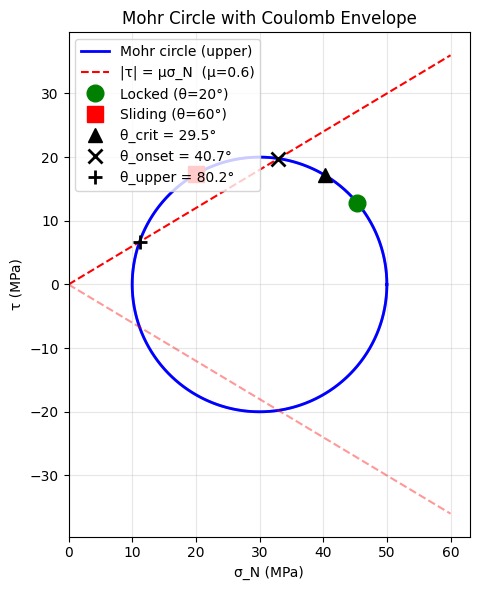

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

sN_on, tau_on = mohr_tractions(theta_onset)
sN_up, tau_up = mohr_tractions(theta_upper)
ax.plot(sN_on, tau_on, 'kx', ms=10, mew=2, zorder=5,
        label=f'θ_onset = {np.degrees(theta_onset):.1f}°')
ax.plot(sN_up, tau_up, 'k+', ms=10, mew=2, zorder=5,
        label=f'θ_upper = {np.degrees(theta_upper):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 4. Build Conforming Mesh (Locked Test, θ = 20°)

In [7]:
builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_LOCKED,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=CONFORMING_CRACK_MESH,
    verbose=True,
)
mesh, el_p, el_u, crack, h_mesh = builder.build()

print(f"h ≈ {h_mesh:.4f},  elements = {mesh.nelements},  vertices = {mesh.p.shape[1]}")


Triangle mesh: 4284 elements, h=0.5000
[RobustCrackGenerator] KDTree facet query: 85 candidates, 25 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 32 | t-range=[0.000, 1.000]
[RobustCrackGenerator] 41 good facets (BOTH endpoints within h), 32 direct hits
[RobustCrackGenerator] Final: 41 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 15 facets, t-range=[0.038603, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 23 facets
[EXTEND] Iteration 1: adding 2 facets towards start
[EXTEND] Final: 17 facets, t-range=[0.000000, 1.000000]
[EXTEND] Starting with 17 facets, t-range=[0.000000, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 22 facets
[EXTEND] Final: 17 facets, t-range=[0.000000, 1.000000]
[RobustCrackGenerator] Articulation points: 13, removable: 4
[RobustCrackGenerator] Duplicate r


Mesh: 2223 vertices, 4284 elements
Crack: 15 surrogate facets
h = 0.5
h ≈ 0.5000,  elements = 4284,  vertices = 2223


## 5. Assemble CG Solver

`crack_law='nonsmooth'` sets K = I (pure displacement-jump evaluator).
`rotate_crack_to_nt=True` separates normal and tangential DOFs at the crack interface.
Roller BCs: left (v₁ = 0), bottom (v₂ = 0).  No traction BCs — the entire background
stress is carried by s0/w0 offsets.

In [8]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    bc = make_bc()

    poro = CGPoroelastostatics(
        mesh=mesh,
        element_p=el_p,
        element_u=el_u,
        params=PARAMS, material=MATERIAL,
        crack=crack,
        model_params=CRACK_MODEL_PARAMS,
        intorder=6,
        scales=(SCALE_L, SCALE_EPS),
        bc=bc,
        P_scale=None,
        verbose=True,
        free_memory=False,
        enforcement_type='nodal',
        apply_transform=True,
        include_taylor=INCLUDE_TAYLOR,
        include_taylor_test=INCLUDE_TAYLOR_TEST,
        include_hessian=INCLUDE_HESSIAN,
        include_sbm=INCLUDE_SBM,
        taylor_method='nodal',
        lumped_coupling='consistent',
        crack_law='nonsmooth',
        rotate_crack_to_nt=True,
        bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    )

    print(f"ndofs = {poro.ndofs}")
    print(f"  Np = {poro.basis_p.N},  Nu = {poro.basis_u.N}")
    print(f"  n_lambda_q = {poro.n_lambda_q},  n_lambda_sigma = {poro.n_lambda_sigma}")
    print(f"  crack_law = nonsmooth,  rotated_to_nt = {poro._transform_info.get('rotated_to_nt')}")

Mesh split along crack:
  Original: 2223 vertices, 4284 elements
  Split: 2237 vertices, 4284 elements
  Crack facets: 15 plus, 15 minus


  Projected 0 / 60 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 15
  Number of DOFs: 2237
  Size: 4320 B
  Projected 0 / 60 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x758413f86e50>
  Projected 0 / 60 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 15
  Number of DOFs: 13042
  Size: 23040 B
  Projected 0 / 60 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x758418598610>
SBM geometry cache: 240 QPs pre-computed in 1.7 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 0.00e+00 (dimensionless: 0.00e+00)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcement type: nodal
Nodal enforcement: 14 interface node pairs (2×14 = 28 flux DOFs)
Augmented system assembled: 15363 DOFs
  = 2237 (p) + 13

### 5a. True crack vs SBM surrogate (locked mesh)


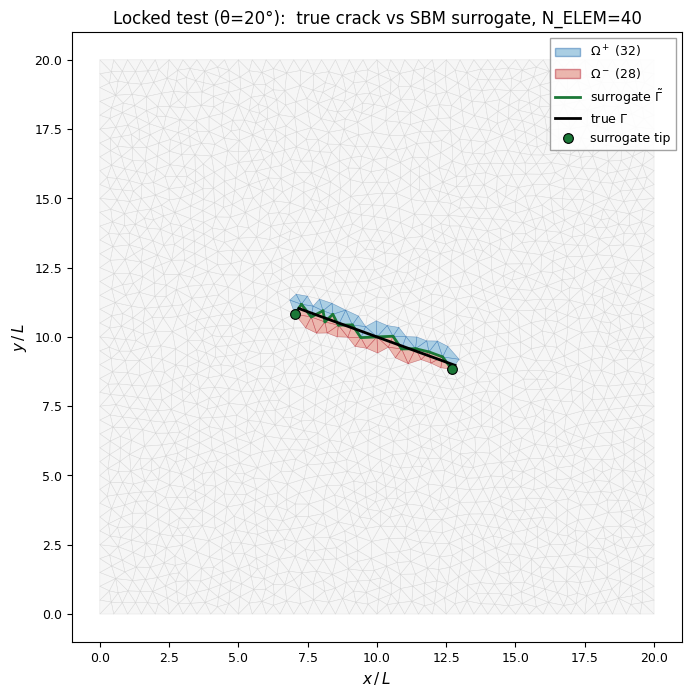

In [9]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    fig_sides, ax_sides = poro.plot_element_sides(
        show_true_crack=True,
        show_surrogate_crack=True,
        show_true_tips=True,
        show_surrogate_tips=True,
    )
    ax_sides.set_title(
        f'Locked test (\u03b8={np.degrees(THETA_LOCKED):.0f}\u00b0):  '
        f'true crack vs SBM surrogate, N_ELEM={N_ELEM}'
    )
    plt.show()


## 6. Projection and Dynamic System

`strip_multiplier_dynamics()` zeros the multiplier rows of `M` so the algebraic
projection owns them.  `build_projection()` builds the constraint projection.
`build_first_order_dynamic_system()` lifts to descriptor form `A_dyn · ẋ = rhs(t, x)`.

In [10]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    poro.strip_multiplier_dynamics()
    projection, meta = poro.build_projection()

    dyn = poro.build_first_order_dynamic_system(meta)

    A_dyn          = dyn['A']
    rhs_dyn        = dyn['rhs']
    rhs_jac_dyn    = dyn['rhs_jac']
    velocity_slice = dyn['velocity_slice']
    n_base         = dyn['n_base']
    comp_slices    = dyn['component_slices']
    nl_atol_dyn    = dyn['nl_atol_per_block']

    Np = poro.basis_p.N
    Nu = poro.basis_u.N

    print(f"n_base = {n_base},  |x| = {A_dyn.shape[0]},  nnz(A_dyn) = {A_dyn.nnz}")
    print(f"velocity_slice = {velocity_slice}")
    print(f"component_slices: {len(comp_slices)} blocks")

build_projection():
  Flux constraint:     C_q shape=(28, 15279)
  Traction constraint: C_s shape=(56, 15279)
  Projection type:     AlgebraicConstraintProjection
  Component slices:    13 blocks


n_base = 15363,  |x| = 28405,  nnz(A_dyn) = 118976
velocity_slice = slice(15363, np.int32(28405), None)
component_slices: 18 blocks


### 6a. Descriptor Pencil Diagnostics

In [11]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    A_csr = A_dyn.tocsr()
    J_csr = rhs_jac_dyn(0.0, np.zeros(A_dyn.shape[0])).tocsr()

    row_p   = slice(0, Np)
    row_u   = slice(Np, Np + Nu)
    row_lam = slice(Np + Nu, n_base)
    row_mom = slice(n_base, n_base + Nu)

    def fro(block):
        return float(sp.linalg.norm(block, 'fro')) if block.nnz else 0.0

    print("=== A_dyn block norms (descriptor mass) ===")
    print(f"  ||A[p, z]||   = {fro(A_csr[row_p, :n_base]):.3e}")
    print(f"  ||A[kin, z]||  = {fro(A_csr[row_u, :n_base]):.3e}")
    print(f"  ||A[lam, :]||  = {fro(A_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
    print(f"  ||A[mom, v]||  = {fro(A_csr[row_mom, n_base:]):.3e}  (FE inertia)")
    print()
    print("=== J_dyn block norms (RHS Jacobian) ===")
    print(f"  ||J[mom, z]||  = {fro(J_csr[row_mom, :n_base]):.3e}  (stiffness)")
    print(f"  ||J[mom, v]||  = {fro(J_csr[row_mom, n_base:]):.3e}  (damping)")

=== A_dyn block norms (descriptor mass) ===
  ||A[p, z]||   = 1.349e+01
  ||A[kin, z]||  = 1.142e+02
  ||A[lam, :]||  = 0.000e+00  (expect 0 — stripped)
  ||A[mom, v]||  = 7.871e+00  (FE inertia)

=== J_dyn block norms (RHS Jacobian) ===
  ||J[mom, z]||  = 4.807e+02  (stiffness)
  ||J[mom, v]||  = 4.326e+02  (damping)


## 7. Projected Radau Contact Wiring

Build extraction matrices and traction coupling directly from `_transform_info` offsets.
With `rotate_crack_to_nt=True`, the transformed state exposes `[[u_n]]` and `[[u_t]]`
as contiguous blocks at known offsets.

- `C_extract` selects displacement jumps `[[u_n]], [[u_t]]` from the dynamic state.
- `D_extract` selects velocity jumps `[[v_n]], [[v_t]]` from the explicit velocity block.
- `B` is the weak-form traction distribution from the transformed `[[λ_σ]]` columns.

The contact solver receives effective nodal tractions.  Interface quadrature weights stay
inside `B`; Mohr offsets are therefore passed as pure nodal tractions, not multiplied by
`omega`.  The Biot pressure part of the normal total traction is split into the smooth
RHS as `-α B_n C_{p,Γ} x`, so mechanics still receives total traction while the cone sees
effective normal traction.


In [12]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    info = poro._transform_info
    n_c  = int(poro.n_lambda_q)
    dim  = int(poro.dim)

    lam_s_sl = meta['lam_s_sl']

    off_jmpu  = info['off_jmpu']
    n_iu      = info['n_intf_u']
    off_jmpls = info['off_jmpls']
    n_lsig    = info['n_lam_sig']

    # With rotate_crack_to_nt: [[u_n]](n_c) then [[u_t]](n_c)
    jmpu_n_indices = np.arange(off_jmpu, off_jmpu + n_c)
    jmpu_t_indices = np.arange(off_jmpu + n_c, off_jmpu + n_iu)
    jmpu_all = np.concatenate([jmpu_n_indices, jmpu_t_indices])

    jmpls_cols = np.arange(off_jmpls, off_jmpls + n_lsig)

    print(f"Interface nodes:  n_c = {n_c}")
    print(f"[[u_n]] indices:  {jmpu_n_indices[0]}..{jmpu_n_indices[-1]}")
    print(f"[[u_t]] indices:  {jmpu_t_indices[0]}..{jmpu_t_indices[-1]}")
    print(f"[[λ_σ]] columns:  {jmpls_cols[0]}..{jmpls_cols[-1]}")

    T_u_mat = dyn['T_u']
    u_idx   = dyn['u_state_indices']
    jmpu_local = np.searchsorted(u_idx, jmpu_all)
    assert np.all(u_idx[jmpu_local] == jmpu_all), "[[u]] DOFs not found in u_state"
    D = T_u_mat[jmpu_local, :].tocsr()

    R_v = dyn.get('R_v')
    A_csr = poro.A.tocsr()
    B_u = (A_csr[Np:Np + Nu, :][:, jmpls_cols]).tocsr()
    if R_v is not None:
        B_u = (R_v @ B_u).tocsr()

    dirichlet_local = np.array(
        [d - Np for d in np.asarray(getattr(poro, '_dirichlet_dof_set', []), dtype=int)
         if Np <= d < Np + Nu],
        dtype=int,
    )
    if dirichlet_local.size:
        B_u = B_u.tolil()
        B_u[dirichlet_local, :] = 0.0
        B_u = B_u.tocsr()

    scale = h_mesh / 2.0
    err_wc = sp.linalg.norm(B_u - scale * D.T) / sp.linalg.norm(B_u)
    print(f"\nUniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc:.2e}")
    print("  Exact contact weights are checked below through D_contact @ B.")

    # Projected Radau reactions are ordered per contact block:
    # [r_n0, r_t0, r_n1, r_t1, ...].  The transformed λ jump columns are
    # grouped [all σ_n, all τ], so permute B into contact-block order.
    perm = [idx for k in range(n_c) for idx in (k, n_c + k)]
    B_u_perm = B_u[:, perm].tocsr()
    reaction_rows = np.array([row for k in range(n_c) for row in (k, n_c + k)], dtype=int)

    contacts = [
        {
            'vel_normal_idx': k,
            'vel_tangential_idx': [n_c + k],
            'mu': MU,
            'e': 0.0,
        }
        for k in range(n_c)
    ]

    print(f"\nContact blocks: {len(contacts)}")


Interface nodes:  n_c = 14
[[u_n]] indices:  15251..15264
[[u_t]] indices:  15265..15278
[[λ_σ]] columns:  15335..15362

Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 1.01e+00
  Exact contact weights are checked below through D_contact @ B.

Contact blocks: 14


In [13]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    # Build first-order dynamic contact matrices in the augmented physical state y=[z; v].
    n_phys_locked = A_dyn.shape[0]
    n_aug_phys = n_phys_locked
    n_vel = n_aug_phys - n_base
    n_extract = 2 * n_c

    # Gap rows are grouped [all [[u_n]], all [[u_t]]] in the transformed base state.
    gap_extract_dyn = sp.csr_matrix(
        (np.ones(n_extract), (np.arange(n_extract), jmpu_all)),
        shape=(n_extract, n_aug_phys),
    )

    # Velocity rows use the explicit velocity block returned by build_first_order_dynamic_system.
    vel_extract_dyn = sp.hstack(
        [sp.csr_matrix((n_extract, n_base)), D],
        format='csr',
    )

    # Weak-form traction coupling.  B_u_perm columns are already in contact-block order.
    B_c_dyn = sp.vstack(
        [sp.csr_matrix((n_base, B_u_perm.shape[1])), B_u_perm],
        format='csr',
    )
    B_dyn = B_c_dyn
    B_n_dyn = B_c_dyn[:, 0::2]
    B_t_dyn = B_c_dyn[:, 1::2]

    # Contact-space work-conjugacy check in the same interleaved order used by Radau.
    vel_contact_extract_dyn = vel_extract_dyn[reaction_rows, :].tocsr()
    M_cc = (vel_contact_extract_dyn @ B_c_dyn).toarray()
    off_diag = np.max(np.abs(M_cc - np.diag(np.diag(M_cc))))
    omega = np.diag(M_cc)
    omega_n = omega[0::2]
    omega_t = omega[1::2]
    # print(f"D_contact @ B diag range: {omega.min():.3e} .. {omega.max():.3e}; offdiag max {off_diag:.3e}")
    # assert np.all(omega > 0), "Expected positive weak-form interface weights"
    # if USE_SBM:
    #     assert off_diag <= 1e-3 * max(1.0, np.max(np.abs(omega))), \
    #         f"off-diag {off_diag:.3e} exceeds SBM tol vs diag {np.max(np.abs(omega)):.3e}"
    # else:
    #     assert off_diag < 1e-10 * max(1.0, np.max(np.abs(omega))), "D_contact @ B should be diagonal for nodal contact"
    # if USE_SBM:
    #     _diff = np.max(np.abs(omega_n - omega_t))
    #     _max  = max(1.0, np.max(np.abs(omega_n)))
    #     assert _diff <= 1e-3 * _max, f"omega_n vs omega_t mismatch {_diff:.3e} > tol"
    # else:
    #     assert np.allclose(omega_n, omega_t, rtol=1e-12, atol=1e-12)

    # Crack pressure trace used by the later alpha-coupled effective-traction split.
    # For the alpha-zero validation this contributes exactly zero, but keeping the
    # matrix explicit prevents the mechanics/cone split from drifting later.
    off_avgp = info['off_avgp']
    n_intf_p = info['n_intf_p']
    assert n_intf_p == n_c, "This notebook assumes one pore-pressure trace value per contact node"
    # Taylor-shifted average pressure trace at the actual crack face:
    # 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
    # y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
    T_inv_p_static = poro._T_inv[0:Np, :].tocsr()
    P_old_from_dyn = sp.hstack(
        [T_inv_p_static,
         sp.csr_matrix((Np, n_aug_phys - T_inv_p_static.shape[1]))],
        format='csr',
    )
    p_gamma_extract_dyn = (
        0.5 * (poro.C_exp_p_plus + poro.C_exp_p_minus) @ P_old_from_dyn
    ).tocsr()
    pressure_normal_correction = -ALPHA_BIOT * (B_n_dyn @ p_gamma_extract_dyn)
    pressure_normal_correction.eliminate_zeros()

    # # Alpha-zero verification: mechanics and cone tractions coincide in this phase.
    # assert ALPHA_BIOT == 0.0, "Alpha-zero validation expects ALPHA_BIOT = 0.0"
    # assert gap_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert vel_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert vel_contact_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert B_c_dyn.shape == (n_aug_phys, n_extract)
    # assert B_n_dyn.shape == (n_aug_phys, n_c)
    # assert B_t_dyn.shape == (n_aug_phys, n_c)
    # assert p_gamma_extract_dyn.shape == (n_c, n_aug_phys)
    # assert pressure_normal_correction.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
    # print("Alpha-zero matrix/unit checks: PASS")

    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

    if USE_LYSMER:
        _C_lysmer_locked = lysmer_descriptor_block(
            poro, n_phys_locked, n_base, a_p=LYSMER_AP, a_s=LYSMER_AS,
        )
    else:
        _C_lysmer_locked = None

    def rhs_dyn_eff(t, y, *extra):
        out = rhs_dyn(t, y, *extra) + pressure_normal_correction @ y
        if _C_lysmer_locked is not None:
            out = out - _C_lysmer_locked @ y
        return out

    def rhs_jac_dyn_eff(t, y, *extra):
        J = rhs_jac_dyn(t, y, *extra) + pressure_normal_correction
        if _C_lysmer_locked is not None:
            J = J - _C_lysmer_locked
        return J


In [14]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    # Locked case: pure effective-traction offsets (not multiplied by interface weights).
    sigma_N_locked, tau_locked_val = mohr_tractions(THETA_LOCKED)
    _sN_phys, _tau_phys = prestress_offsets(sigma_N_locked, tau_locked_val)
    _s0_val = np.full(n_c, _sN_phys / Sigma_scale)
    _w0_val = np.full(n_c, _tau_phys / Sigma_scale)
    # assert _s0_val.shape == (n_c,)
    # assert _w0_val.shape == (n_c,)
    # assert np.allclose(_s0_val, sigma_N_locked / Sigma_scale)
    # assert np.allclose(_w0_val, tau_locked_val / Sigma_scale)

    def get_s0_locked(y):
        return _s0_val

    def get_w0_locked(y, k):
        return np.array([_w0_val[int(k)]])

    # Keep the flux Robin law algebraic.  Replace the whole transformed traction
    # closure row by zero; contact supplies the effective traction through B_c_dyn.
    flux_constraint = meta['constraints'][0]
    n_lam_s_dim = int(lam_s_sl.stop - lam_s_sl.start)
    zero_lam_s = {
        'g': lambda zf, *_a, _n=n_lam_s_dim: np.zeros(_n),
        'dg_dy': lambda zf, *_a, _n=n_lam_s_dim: np.zeros((_n, _n)),
        'y_slice': lam_s_sl,
        'q_slice': lam_s_sl,
    }

    cs = build_projected_radau_contact(
        A_dyn,
        rhs_dyn_eff,
        np.zeros(A_dyn.shape[0]),
        contacts=contacts,
        C_extract=gap_extract_dyn,
        D_extract=vel_extract_dyn,
        B=B_c_dyn,
        constraints=[flux_constraint, zero_lam_s],
        component_slices=comp_slices,
        rhs_jac=rhs_jac_dyn_eff,
        get_s0=get_s0_locked,
        get_w0=get_w0_locked,
        normal_r='auto',
        friction_r='auto',
        endpoint_inactive_handling='natural_map',
        contact_law=CONTACT_LAW,
        reported_reaction_units='force',
        auto_rho_strategy='delassus',
    )
    print("locked contact system:", cs.A.shape, "unknowns", cs.y0.size, "pure traction offsets")


locked contact system: (28433, 28433) unknowns 28433 pure traction offsets


## 8. Initial Condition

Zero perturbation everywhere — the background stress is entirely in s0/w0.

In [15]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    y0_locked = cs.y0.copy()
    y0_locked[-2 * n_c:] = coulomb_cone_warm_start(_s0_val, _w0_val, MU)

    print(f"|y0| = {np.linalg.norm(y0_locked):.4e}")
    print(f"  (should be ~0 — pure perturbation problem)")

|y0| = 0.0000e+00
  (should be ~0 — pure perturbation problem)


## 9. Solve — Locked Test (θ = 20° < θ_onset)

The resolved shear stress is below the Coulomb threshold, so the crack should remain
locked: zero perturbation displacement, zero slip.

In [16]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    n_aug_locked = cs.y0.size
    n_phys_locked = A_dyn.shape[0]

    nl_atol_locked = np.full(n_aug_locked, 1e-8)
    nl_rtol_locked = np.full(n_aug_locked, 1e-6)
    nl_atol_locked[n_phys_locked:] = 1e-10
    nl_rtol_locked[n_phys_locked:] = 0.0

    solver_opts_locked = dict(cs.solver_opts)
    solver_opts_locked.update(
        tol=1e-12,
        max_iter=500,
        rhs_jac=cs.rhs_jac,
        linear_solver='petsc',
        petsc_options={
            'ksp_type': 'preonly',
            'pc_type': 'lu',
            'pc_factor_mat_solver_type': 'mumps',
        },
    )

    integrator_opts_locked = dict(cs.integrator_opts)
    integrator_opts_locked.update({'stages': 2, 'use_coupled_newton': True})


    print(
        f"Solving locked test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), "
        f"h0={H0_ADAPTIVE}, tmax={TMAX}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}"
    )

    (
        t_locked, y_locked, h_locked, fk_locked, info_locked, attempts_locked
    ) = solve_nivp.solve_ivp_ns(
        fun=cs.rhs,
        t_span=(0, TMAX),
        y0=y0_locked,
        method='radau_iia',
        integrator_opts=integrator_opts_locked,
        projection=cs.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs.component_slices},
        solver_opts=solver_opts_locked,
        adaptive=True,
        h0=H0_ADAPTIVE,
        rtol=ADAPTIVE_RTOL,
        atol=ADAPTIVE_ATOL,
        skip_error_indices=[0],
        active_set_filter=False,
        return_attempts=True,
        adaptive_opts=dict(
            h0=H0_ADAPTIVE,
            h_min=ADAPTIVE_H_MIN,
            h_max=ADAPTIVE_H_MAX,
            h_up=2.0,
            h_down=0.5,
            method_order=1,
        ),
        nl_atol=nl_atol_locked,
        nl_rtol=nl_rtol_locked,
        component_slices=cs.component_slices,
        verbose=True,
        A=cs.A,
        dae_var_weight='auto',
    )

    h_arr_locked = np.asarray(h_locked, dtype=float)
    acc_locked = np.asarray(attempts_locked, dtype=bool) if attempts_locked is not None else None
    n_acc_locked = int(acc_locked.sum()) if acc_locked is not None else len(t_locked) - 1
    n_rej_locked = int((~acc_locked).sum()) if acc_locked is not None else 0
    print(
        f"Done: {len(t_locked)} states, t_final = {t_locked[-1]:.4e}; "
        f"steps accepted={n_acc_locked}, rejected={n_rej_locked}; "
        f"h range=[{h_arr_locked.min():.2e}, {h_arr_locked.max():.2e}], "
        f"median h={np.median(h_arr_locked):.2e}"
    )

    y_final = y_locked[-1]
    u_pert_max = np.max(np.abs(y_final[:n_base]))
    v_pert_max = np.max(np.abs(y_final[n_base:n_phys_locked]))
    r_pert_final = y_final[n_phys_locked:n_phys_locked + 2*n_c]
    print(f"locked max |z|={u_pert_max:.3e}, max |v|={v_pert_max:.3e}, max |r_pert|={np.max(np.abs(r_pert_final)):.3e}")

    locked_gap = np.asarray(y_locked[:, jmpu_n_indices], dtype=float)
    locked_slip = np.asarray(y_locked[:, jmpu_t_indices], dtype=float)
    locked_vjump = np.asarray((vel_extract_dyn @ y_locked[:, :n_phys_locked].T).T, dtype=float)
    locked_vn = locked_vjump[:, :n_c]
    locked_vt = locked_vjump[:, n_c:]
    r_pert_locked, r_total_locked_nd, r_n_locked_nd, r_t_locked_nd = _contact_history(
        y_locked, n_phys_locked, n_c, _s0_val, _w0_val
    )
    r_n_locked = r_n_locked_nd * Sigma_scale
    r_t_locked = r_t_locked_nd * Sigma_scale
    locked_cone_margin = MU * r_n_locked - np.abs(r_t_locked)
    locked_constraint_inf = _constraint_residual_inf(cs.projected_radau_contact, y_final[:n_phys_locked])

    locked_tol = 1e-7
    locked_checks = {
        "gap_nonnegative": float(np.min(locked_gap)) >= -1e-10,
        "normal_jump_velocity_small": float(np.max(np.abs(locked_vn))) <= locked_tol,
        "slip_small": float(np.max(np.abs(locked_slip))) <= locked_tol,
        "tangential_jump_velocity_small": float(np.max(np.abs(locked_vt))) <= locked_tol,
        "reaction_perturbation_small": float(np.max(np.abs(r_pert_locked))) <= locked_tol,
        "cone_strictly_inside": float(np.min(locked_cone_margin)) > 1e-6,
        "constraints_satisfied": locked_constraint_inf <= locked_tol,
    }
    for name, ok in locked_checks.items():
        print(f"locked check {name}: {ok}")
    print(f"locked cone margin MPa: min={locked_cone_margin.min():.6f}, max={locked_cone_margin.max():.6f}")
    print(f"locked constraint residual inf: {locked_constraint_inf:.3e}")
    locked_checks_pass = all(locked_checks.values())
    assert locked_checks_pass, locked_checks
    print("LOCKED validation: PASS")


Solving locked test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), h0=1.008115219752334, tmax=108.01234497346434, rtol=0.001, atol=1e-06


[adaptive/DAE] detected 112 algebraic DOFs (of 28433 total) — excluded from error norm
[adaptive/emb] accept @ t=0 -> t+1.008e+00, E=0.000e+00, h_next=2.016e+00


[adaptive/emb] accept @ t=1.00812 -> t+2.016e+00, E=0.000e+00, h_next=4.032e+00


[adaptive/emb] accept @ t=3.02435 -> t+4.032e+00, E=0.000e+00, h_next=8.065e+00


[adaptive/emb] accept @ t=7.05681 -> t+8.065e+00, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=15.1217 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=25.923 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=36.7242 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01


[adaptive/emb] accept @ t=47.5254 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=58.3267 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=69.1279 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=79.9291 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01


[adaptive/emb] accept @ t=90.7304 -> t+1.080e+01, E=0.000e+00, h_next=1.080e+01
[adaptive/emb] accept @ t=101.532 -> t+6.481e+00, E=0.000e+00, h_next=1.080e+01
Done: 14 states, t_final = 1.0801e+02; steps accepted=1, rejected=0; h range=[1.01e+00, 1.08e+01], median h=1.08e+01
locked max |z|=0.000e+00, max |v|=0.000e+00, max |r_pert|=0.000e+00
locked check gap_nonnegative: True
locked check normal_jump_velocity_small: True
locked check slip_small: True
locked check tangential_jump_velocity_small: True
locked check reaction_perturbation_small: True
locked check cone_strictly_inside: True
locked check constraints_satisfied: True
locked cone margin MPa: min=14.336781, max=14.336781
locked constraint residual inf: 0.000e+00
LOCKED validation: PASS


### 9a. Dashboard — Locked

Full-field contour plots of the perturbation.  Everything should be near-zero.

In [17]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    z_locked = y_locked[:, :n_base]

    fields_locked = poro.sol_to_fields_dict_with_dimensions(
        np.asarray(t_locked),
        z_locked.T,
        use_taylor_correction=True,
        constrained_l2=False,
    )
    fields_locked['y_raw'] = z_locked.T
    fields_locked['t_raw'] = np.asarray(t_locked)

    dashboard_locked = CGPoroelasticDashboard(poro, fields_locked, levels=40)
    dashboard_locked.show()


## 10. Solve — Sliding Test (θ = 27° ∈ failure zone)

Rebuild the same alpha-zero projected-Radau system with a prestress outside the Mohr-Coulomb cone. The total effective traction should be projected to the cone, tangential traction should oppose slip, and the gap should remain nonnegative.


In [18]:
builder_s = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_SLIDING,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=CONFORMING_CRACK_MESH,
    verbose=True,
)
mesh_s, el_p_s, el_u_s, crack_s, h_mesh_s = builder_s.build()

bc_s = make_bc()

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s,
    element_u=el_u_s,
    params=PARAMS, material=MATERIAL,
    crack=crack_s,
    model_params=CRACK_MODEL_PARAMS,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=INCLUDE_TAYLOR,
        include_taylor_test=INCLUDE_TAYLOR_TEST,
    include_hessian=INCLUDE_HESSIAN,
    include_sbm=INCLUDE_SBM,
    taylor_method='nodal',
    lumped_coupling='consistent',
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f"Sliding mesh: {mesh_s.nelements} elements, {mesh_s.p.shape[1]} vertices")
print(f"n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}")


Triangle mesh: 4284 elements, h=0.5000
[RobustCrackGenerator] KDTree facet query: 90 candidates, 34 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 45 | t-range=[0.000, 0.995]
[RobustCrackGenerator] 58 good facets (BOTH endpoints within h), 45 direct hits
[RobustCrackGenerator] Final: 58 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 16 facets, t-range=[0.000000, 0.994816]
[EXTEND] Global t-range=[0.000000, 0.994816]
[EXTEND] Initial frontier (start): 39 facets
[EXTEND] Final: 16 facets, t-range=[0.000000, 0.994816]
[EXTEND] Starting with 16 facets, t-range=[0.000000, 0.994816]
[EXTEND] Global t-range=[0.000000, 0.994816]
[EXTEND] Initial frontier (start): 39 facets
[EXTEND] Final: 16 facets, t-range=[0.000000, 0.994816]
[RobustCrackGenerator] Articulation points: 14, removable: 2
[RobustCrackGenerator] Selected 16 connected facets
[RobustCrackGenerator] Selected t-


Mesh: 2223 vertices, 4284 elements
Crack: 16 surrogate facets
h = 0.5


Mesh split along crack:
  Original: 2223 vertices, 4284 elements
  Split: 2238 vertices, 4284 elements
  Crack facets: 15 plus, 15 minus


  Projected 0 / 60 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 15
  Number of DOFs: 2238
  Size: 4320 B
  Projected 0 / 60 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x75840513f5d0>
  Projected 0 / 60 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 15
  Number of DOFs: 13044
  Size: 23040 B
  Projected 0 / 60 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x75840513e2d0>
SBM geometry cache: 240 QPs pre-computed in 1.6 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 0.00e+00 (dimensionless: 0.00e+00)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcement type: nodal
Nodal enforcement: 15 interface node pairs (2×15 = 30 flux DOFs)
Augmented system assembled: 15372 DOFs
  = 2238 (p) + 13

Sliding mesh: 4284 elements, 2223 vertices
n_base = 15372, |x| = 28416


### 10aa. True crack vs SBM surrogate (sliding mesh)


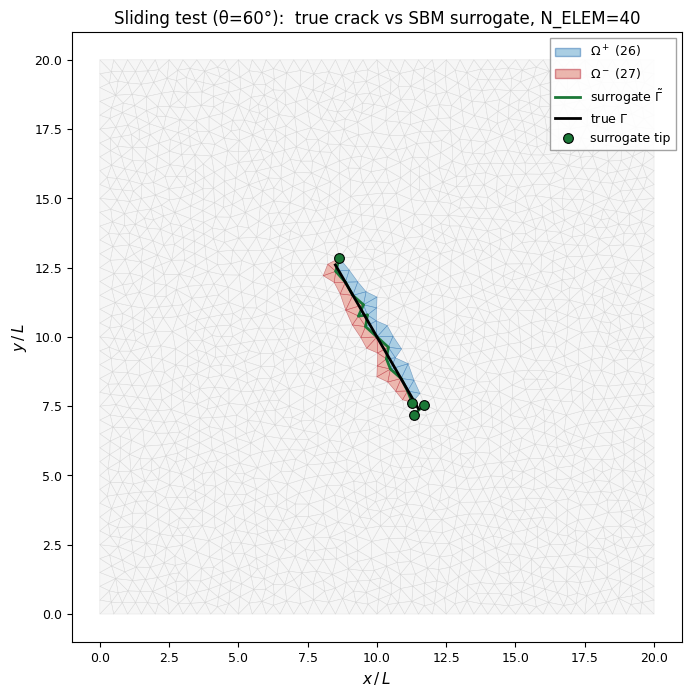

In [19]:
fig_sides_s, ax_sides_s = poro_s.plot_element_sides(
    show_true_crack=True,
    show_surrogate_crack=True,
    show_true_tips=True,
    show_surrogate_tips=True,
)
ax_sides_s.set_title(
    f'Sliding test (\u03b8={np.degrees(THETA_SLIDING):.0f}\u00b0):  '
    f'true crack vs SBM surrogate, N_ELEM={N_ELEM}'
)
plt.show()


In [20]:

info_s = poro_s._transform_info
n_c_s  = int(poro_s.n_lambda_q)

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)

T_u_s = dyn_s['T_u']
u_idx_s = dyn_s['u_state_indices']
jmpu_local_s = np.searchsorted(u_idx_s, jmpu_all_s)
assert np.all(u_idx_s[jmpu_local_s] == jmpu_all_s)
D_s = T_u_s[jmpu_local_s, :].tocsr()

R_v_s = dyn_s.get('R_v')
A_csr_s = poro_s.A.tocsr()
B_u_s = (A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc_s:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()
reaction_rows_s = np.array([row for k in range(n_c_s) for row in (k, n_c_s + k)], dtype=int)

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_phys_s = A_dyn_s.shape[0]
n_aug_phys_s = n_phys_s
n_vel_s = n_aug_phys_s - n_base_s
n_extract_s = 2 * n_c_s

gap_extract_dyn_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_aug_phys_s),
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, n_base_s)), D_s],
    format='csr',
)
B_c_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)
B_dyn_s = B_c_dyn_s
B_n_dyn_s = B_c_dyn_s[:, 0::2]
B_t_dyn_s = B_c_dyn_s[:, 1::2]

vel_contact_extract_dyn_s = vel_extract_dyn_s[reaction_rows_s, :].tocsr()
M_cc_s = (vel_contact_extract_dyn_s @ B_c_dyn_s).toarray()
off_diag_s = np.max(np.abs(M_cc_s - np.diag(np.diag(M_cc_s))))
omega_s = np.diag(M_cc_s)
omega_n_s = omega_s[0::2]
omega_t_s = omega_s[1::2]
print(f"sliding D_contact @ B diag range: {omega_s.min():.3e} .. {omega_s.max():.3e}; offdiag max {off_diag_s:.3e}")
# if USE_SBM:
#     print(f"  [SBM] omega_n range: {float(omega_n_s.min()):.3e} .. {float(omega_n_s.max()):.3e}")
#     print(f"  [SBM] omega_t range: {float(omega_t_s.min()):.3e} .. {float(omega_t_s.max()):.3e}")
#     print(f"  [SBM] omega_n - omega_t max: {np.max(np.abs(omega_n_s - omega_t_s)):.3e}")
# assert np.all(omega_s > 0), "Expected positive weak-form interface weights"
# if USE_SBM:
#     assert off_diag_s <= 1e-3 * max(1.0, np.max(np.abs(omega_s))), f"off-diag {off_diag_s:.3e} exceeds SBM tol vs diag {np.max(np.abs(omega_s)):.3e}"
# else:
#     assert off_diag_s < 1e-10 * max(1.0, np.max(np.abs(omega_s)))
# if USE_SBM:
#     _diff = np.max(np.abs(omega_n_s - omega_t_s))
#     _max  = max(1.0, np.max(np.abs(omega_n_s)))
#     assert _diff <= 1e-3 * _max, f"omega_n vs omega_t mismatch {_diff:.3e} > tol"
# else:
#     assert np.allclose(omega_n_s, omega_t_s, rtol=1e-12, atol=1e-12)

off_avgp_s = info_s['off_avgp']
n_intf_p_s = info_s['n_intf_p']
assert n_intf_p_s == n_c_s, "This notebook assumes one pore-pressure trace value per contact node"
# Taylor-shifted average pressure trace at the actual crack face:
# 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
# y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
T_inv_p_static_s = poro_s._T_inv[0:Np_s, :].tocsr()
P_old_from_dyn_s = sp.hstack(
    [T_inv_p_static_s,
     sp.csr_matrix((Np_s, n_aug_phys_s - T_inv_p_static_s.shape[1]))],
    format='csr',
)
p_gamma_extract_dyn_s = (
    0.5 * (poro_s.C_exp_p_plus + poro_s.C_exp_p_minus) @ P_old_from_dyn_s
).tocsr()
pressure_normal_correction_s = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
pressure_normal_correction_s.eliminate_zeros()
# assert pressure_normal_correction_s.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
# print("Sliding alpha-zero matrix/unit checks: PASS")

# Keep the sliding branch executable on its own during smoke checks.
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

if '_contact_history' not in globals():
    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

if USE_LYSMER:
    _C_lysmer_sliding = lysmer_descriptor_block(
        poro_s, n_phys_s, n_base_s, a_p=LYSMER_AP, a_s=LYSMER_AS,
    )
else:
    _C_lysmer_sliding = None

if USE_WINKLER:
    _K_winkler_sliding = winkler_descriptor_block(
        poro_s, n_phys_s, n_base_s,
        u_state_indices=dyn_s['u_state_indices'],
        b_p=WINKLER_BP, b_s=WINKLER_BS,
    )
else:
    _K_winkler_sliding = None

def rhs_dyn_s_eff(t, y, *extra):
    out = rhs_dyn_s(t, y, *extra) + pressure_normal_correction_s @ y
    if _C_lysmer_sliding is not None:
        out = out - _C_lysmer_sliding @ y
    if _K_winkler_sliding is not None:
        out = out - _K_winkler_sliding @ y
    return out

def rhs_jac_dyn_s_eff(t, y, *extra):
    J = rhs_jac_dyn_s(t, y, *extra) + pressure_normal_correction_s
    if _C_lysmer_sliding is not None:
        J = J - _C_lysmer_sliding
    if _K_winkler_sliding is not None:
        J = J - _K_winkler_sliding
    return J

sigma_N_sliding, tau_sliding_val = mohr_tractions(THETA_SLIDING)
_sN_phys_s, _tau_phys_s = prestress_offsets(sigma_N_sliding, tau_sliding_val)
_s0_val_s = np.full(n_c_s, 2.0 * _sN_phys_s / Sigma_scale)
_w0_val_s = np.full(n_c_s, 2.0 * _tau_phys_s / Sigma_scale)
assert _s0_val_s.shape == (n_c_s,)
assert _w0_val_s.shape == (n_c_s,)
assert np.allclose(_s0_val_s, 2.0 * _sN_phys_s / Sigma_scale)
assert np.allclose(_w0_val_s, 2.0 * _tau_phys_s / Sigma_scale)

def get_s0_sliding(y):
    return _s0_val_s

def get_w0_sliding(y, k):
    return np.array([_w0_val_s[int(k)]])

flux_constraint_s = meta_s['constraints'][0]
n_lam_s_dim_s = int(lam_s_sl_s.stop - lam_s_sl_s.start)
zero_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros((_n, _n)),
    'y_slice': lam_s_sl_s,
    'q_slice': lam_s_sl_s,
}

cs_s = build_projected_radau_contact(
    A_dyn_s,
    rhs_dyn_s_eff,
    np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    C_extract=gap_extract_dyn_s,
    D_extract=vel_extract_dyn_s,
    B=B_c_dyn_s,
    constraints=[flux_constraint_s, zero_lam_s_s],
    component_slices=comp_slices_s,
    rhs_jac=rhs_jac_dyn_s_eff,
    get_s0=get_s0_sliding,
    
    get_w0=get_w0_sliding,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
)
print("sliding contact system:", cs_s.A.shape, "unknowns", cs_s.y0.size, "pure traction offsets")


Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 1.01e+00
  Exact contact weights are checked below through D_contact @ B.
sliding D_contact @ B diag range: 4.231e-02 .. 3.679e-01; offdiag max 1.153e-01
sliding contact system: (28446, 28446) unknowns 28446 pure traction offsets


In [21]:
n_aug_sliding = cs_s.y0.size
n_phys_sliding = A_dyn_s.shape[0]

nl_atol_sliding = np.full(n_aug_sliding, 1e-8)
nl_rtol_sliding = np.full(n_aug_sliding, 1e-6)
nl_atol_sliding[n_phys_sliding:] = 1e-12
nl_rtol_sliding[n_phys_sliding:] = 1e-8*0

solver_opts_sliding = dict(cs_s.solver_opts)
solver_opts_sliding.update(
    tol=1e-8,
    max_iter=50,
    rhs_jac=cs_s.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
    petsc_reuse_steps=50,
)

integrator_opts_sliding = dict(cs_s.integrator_opts)
integrator_opts_sliding.update({'stages': 2, 'use_coupled_newton': True})

print(
    f"Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), "
    f"h0={H0_ADAPTIVE}, tmax={TMAX}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}"
)

_do_phase_split = (
    LOADING_MODE == 'displacement' and RAMP_HOLD_AFTER and T_LOAD < TMAX
)
_t_phase_end = float(T_LOAD) if _do_phase_split else float(TMAX)

print(f"  phase 1 (ramp): t_span = (0, {_t_phase_end})")

(
    t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding, attempts_sliding
) = solve_nivp.solve_ivp_ns(
    fun=cs_s.rhs,
    t_span=(0, _t_phase_end),
    y0=(lambda _y: (_y.__setitem__(slice(-2*n_c_s, None),
        coulomb_cone_warm_start(_s0_val_s, _w0_val_s, MU)) or _y))(
        cs_s.y0.copy()),
    method='radau_iia',
    integrator_opts=integrator_opts_sliding,
    projection=cs_s.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_s.component_slices},
    solver_opts=solver_opts_sliding,
    adaptive=True,
    h0=H0_ADAPTIVE,
    rtol=ADAPTIVE_RTOL,
    atol=ADAPTIVE_ATOL,
    skip_error_indices=[0, len(cs_s.component_slices) - 1],
    active_set_filter=False,
    return_attempts=True,
    adaptive_opts=dict(
        h0=H0_ADAPTIVE,
        h_min=ADAPTIVE_H_MIN,
        h_max=ADAPTIVE_H_MAX,
        h_up=2.0,
        h_down=0.5,
        method_order=1,
    ),
    nl_atol=nl_atol_sliding,
    nl_rtol=nl_rtol_sliding,
    component_slices=cs_s.component_slices,
    verbose=True,
    A=cs_s.A,
    dae_var_weight='auto',
)

# --- Phase 2: ramp-then-hold ---------------------------------------------
# Rebuild poro_s, the dynamic system, and the projected-Radau contact wrapper
# under the hold BC (top pinned at TOP_COMPRESSION reached at T_LOAD).  Mesh,
# crack, scales, params, viscosity are identical, so the DOF layout matches
# and y_phase1[-1] can be passed straight through as the phase-2 IC.
if _do_phase_split:
    from solve_nivp.projected_radau_contact import build_projected_radau_contact as _bprc

    print(f"  phase 2 (hold): rebuilding poro with bc=make_hold_bc({-TOP_COMPRESSION})…")
    bc_hold = make_hold_bc(-TOP_COMPRESSION)
    poro_h = CGPoroelastostatics(
        mesh=mesh_s, element_p=el_p_s, element_u=el_u_s, params=PARAMS, material=MATERIAL,
        crack=crack_s, model_params=CRACK_MODEL_PARAMS, intorder=6,
        scales=(SCALE_L, SCALE_EPS), bc=bc_hold, P_scale=None,
        verbose=False, free_memory=False,
        enforcement_type='nodal', apply_transform=True,
        include_taylor=False, include_hessian=False, include_sbm=False,
        taylor_method='nodal',
        lumped_coupling='consistent',
        crack_law='nonsmooth', rotate_crack_to_nt=True,
        bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    )
    poro_h.strip_multiplier_dynamics()
    _, meta_h = poro_h.build_projection()
    dyn_h = poro_h.build_first_order_dynamic_system(meta_h)
    A_dyn_h = dyn_h['A']
    rhs_dyn_h = dyn_h['rhs']
    rhs_jac_dyn_h = dyn_h['rhs_jac']
    n_base_h = dyn_h['n_base']
    comp_slices_h = dyn_h['component_slices']

    if A_dyn_h.shape != A_dyn_s.shape:
        raise RuntimeError(
            f"phase-2 DOF layout mismatch: A_dyn_h={A_dyn_h.shape} "
            f"vs A_dyn_s={A_dyn_s.shape}.  bc-driven Dirichlet pattern differs."
        )

    pressure_normal_correction_h = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
    pressure_normal_correction_h.eliminate_zeros()

    if USE_LYSMER:
        _C_lysmer_hold = lysmer_descriptor_block(
            poro_h, A_dyn_h.shape[0], n_base_h, a_p=LYSMER_AP, a_s=LYSMER_AS,
        )
    else:
        _C_lysmer_hold = None

    def rhs_dyn_h_eff(t, y, *extra):
        out = rhs_dyn_h(t, y, *extra) + pressure_normal_correction_h @ y
        if _C_lysmer_hold is not None:
            out = out - _C_lysmer_hold @ y
        return out

    def rhs_jac_dyn_h_eff(t, y, *extra):
        J = rhs_jac_dyn_h(t, y, *extra) + pressure_normal_correction_h
        if _C_lysmer_hold is not None:
            J = J - _C_lysmer_hold
        return J

    flux_constraint_h = meta_h['constraints'][0]
    cs_h = _bprc(
        A_dyn_h, rhs_dyn_h_eff, np.zeros(A_dyn_h.shape[0]),
        contacts=contacts_s,
        C_extract=gap_extract_dyn_s,
        D_extract=vel_extract_dyn_s,
        B=B_c_dyn_s,
        constraints=[flux_constraint_h, zero_lam_s_s],
        component_slices=comp_slices_h,
        rhs_jac=rhs_jac_dyn_h_eff,
        get_s0=get_s0_sliding, get_w0=get_w0_sliding,
        normal_r='auto', friction_r='auto',
        endpoint_inactive_handling='natural_map',
        contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    )

    y0_phase2 = y_sliding[-1].copy()
    if y0_phase2.size != cs_h.y0.size:
        raise RuntimeError(
            f"phase-2 IC size mismatch: y0={y0_phase2.size} vs cs_h.y0={cs_h.y0.size}"
        )

    print(f"  phase 2 (hold): t_span = ({_t_phase_end}, {TMAX})")
    (
        t_p2, y_p2, h_p2, fk_p2, info_p2, attempts_p2
    ) = solve_nivp.solve_ivp_ns(
        fun=cs_h.rhs,
        t_span=(_t_phase_end, float(TMAX)),
        y0=y0_phase2,
        method='radau_iia',
        integrator_opts={**dict(cs_h.integrator_opts), 'stages': 2, 'use_coupled_newton': True},
        projection=cs_h.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs_h.component_slices},
        solver_opts={**dict(cs_h.solver_opts), 'tol': 1e-8, 'max_iter': 500,
                     'rhs_jac': cs_h.rhs_jac, 'linear_solver': 'petsc',
                     'petsc_options': {'ksp_type': 'preonly', 'pc_type': 'lu',
                                       'pc_factor_mat_solver_type': 'mumps'}},
        adaptive=True,
        h0=H0_ADAPTIVE, rtol=ADAPTIVE_RTOL, atol=ADAPTIVE_ATOL,
        skip_error_indices=[0, len(cs_h.component_slices) - 1], active_set_filter=False, return_attempts=True,
        adaptive_opts=dict(h0=H0_ADAPTIVE, h_min=ADAPTIVE_H_MIN,
                           h_max=ADAPTIVE_H_MAX, h_up=2.0, h_down=0.5,
                           method_order=1),
        nl_atol=nl_atol_sliding, nl_rtol=nl_rtol_sliding,
        component_slices=cs_h.component_slices,
        verbose=True, A=cs_h.A, dae_var_weight='auto',
    )

    # Concatenate (drop the duplicate state at t = T_LOAD)
    t_sliding = np.concatenate([np.asarray(t_sliding), np.asarray(t_p2)[1:]])
    y_sliding = np.concatenate([np.asarray(y_sliding), np.asarray(y_p2)[1:]], axis=0)
    h_sliding = np.concatenate([np.asarray(h_sliding), np.asarray(h_p2)[1:]])
    fk_sliding = (np.concatenate([np.asarray(fk_sliding), np.asarray(fk_p2)[1:]], axis=0)
                  if fk_sliding is not None and fk_p2 is not None else fk_sliding)
    if attempts_sliding is not None and attempts_p2 is not None:
        attempts_sliding = np.concatenate([np.asarray(attempts_sliding),
                                           np.asarray(attempts_p2)])

    # cs_s now points to the hold-phase model so post-processing
    # diagnostics evaluate the rhs in the phase-2 BC frame.
    cs_s = cs_h
    A_dyn_s = A_dyn_h

h_arr_sliding = np.asarray(h_sliding, dtype=float)
acc_sliding = np.asarray(attempts_sliding, dtype=bool) if attempts_sliding is not None else None
n_acc_sliding = int(acc_sliding.sum()) if acc_sliding is not None else len(t_sliding) - 1
n_rej_sliding = int((~acc_sliding).sum()) if acc_sliding is not None else 0
print(
    f"Done: {len(t_sliding)} states, t_final = {t_sliding[-1]:.4e}; "
    f"steps accepted={n_acc_sliding}, rejected={n_rej_sliding}; "
    f"h range=[{h_arr_sliding.min():.2e}, {h_arr_sliding.max():.2e}], "
    f"median h={np.median(h_arr_sliding):.2e}"
)

y_final_s = y_sliding[-1]
u_pert_max_s = np.max(np.abs(y_final_s[:n_base_s]))
v_pert_max_s = np.max(np.abs(y_final_s[n_base_s:n_phys_s]))
r_pert_final_s = y_final_s[n_phys_s:n_phys_s + 2*n_c_s]
print(f"sliding max |z|={u_pert_max_s:.3e}, max |v|={v_pert_max_s:.3e}, max |r_pert|={np.max(np.abs(r_pert_final_s)):.3e}")

sliding_gap = np.asarray(y_sliding[:, jmpu_n_idx_s], dtype=float)
sliding_slip = np.asarray(y_sliding[:, jmpu_t_idx_s], dtype=float)
sliding_vjump = np.asarray((vel_extract_dyn_s @ y_sliding[:, :n_phys_s].T).T, dtype=float)
sliding_vn = sliding_vjump[:, :n_c_s]
sliding_vt = sliding_vjump[:, n_c_s:]
r_pert_sliding, r_total_sliding_nd, r_n_sliding_nd, r_t_sliding_nd = _contact_history(
    y_sliding, n_phys_s, n_c_s, _s0_val_s, _w0_val_s
)
r_n_sliding = r_n_sliding_nd * Sigma_scale
r_t_sliding = r_t_sliding_nd * Sigma_scale
sliding_cone_margin = MU * r_n_sliding - np.abs(r_t_sliding)
sliding_constraint_inf = _constraint_residual_inf(cs_s.projected_radau_contact, y_final_s[:n_phys_s])

# The IC carries the prestress directly, so its cone margin is negative by
# construction.  Validate the trajectory from the first stepped state onwards.
post_ic = slice(1, None)
sliding_cone_margin_run = sliding_cone_margin[post_ic]
sliding_slip_run = sliding_slip[post_ic]
sliding_vt_run = sliding_vt[post_ic]
final_vt = sliding_vt[-1]
final_slip = sliding_slip[-1]
final_tau = r_t_sliding[-1]
velocity_opposes = bool(np.max(np.abs(final_vt)) <= 1e-10 or np.all(final_tau * final_vt <= 1e-7))
slip_opposes = bool(np.max(np.abs(final_slip)) <= 1e-10 or np.all(final_tau * final_slip <= 1e-7))

sliding_tol = 1e-7
cone_tol_mpa = 1e-2
sliding_checks = {
    "gap_nonnegative": float(np.min(sliding_gap)) >= -1e-10,
    "slip_develops": float(np.max(np.abs(sliding_slip_run))) > 1e-10,
    "cone_not_violated": float(np.min(sliding_cone_margin_run)) >= -cone_tol_mpa,
    "final_total_traction_on_cone": float(np.max(np.abs(sliding_cone_margin[-1]))) <= cone_tol_mpa,
    "traction_opposes_motion_or_slip": velocity_opposes or slip_opposes,
    "constraints_satisfied": sliding_constraint_inf <= sliding_tol,
}
sliding_checks_pass = bool(all(sliding_checks.values()))
import json as _json
with open('/tmp/sliding_checks_results.json', 'w') as _f:
    _payload = {k: bool(v) for k, v in sliding_checks.items()}
    _payload.update({
        'sliding_checks_pass': sliding_checks_pass,
        'min_cone_margin_run_MPa': float(np.min(sliding_cone_margin_run)),
        'max_abs_final_cone_margin_MPa': float(np.max(np.abs(sliding_cone_margin[-1]))),
        'max_abs_slip_run': float(np.max(np.abs(sliding_slip_run))),
        'max_abs_v_t_run': float(np.max(np.abs(sliding_vt_run))),
        'min_gap': float(np.min(sliding_gap)),
        'sliding_constraint_inf': float(sliding_constraint_inf),
        'velocity_opposes': bool(velocity_opposes),
        'slip_opposes': bool(slip_opposes),
    })
    _json.dump(_payload, _f, indent=2)
print(f"sliding_checks_pass = {sliding_checks_pass}")
print(f"sliding_checks = {sliding_checks}")
print(f"sliding cone margin MPa: min(post-IC)={sliding_cone_margin_run.min():.6e}, "
      f"final max abs={np.max(np.abs(sliding_cone_margin[-1])):.6e}")
print(f"sliding constraint residual inf: {sliding_constraint_inf:.3e}")
print(f"SLIDING validation: {'PASS' if sliding_checks_pass else 'FAIL'}")


Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), h0=1.008115219752334, tmax=108.01234497346434, rtol=0.001, atol=1e-06
  phase 1 (ramp): t_span = (0, 108.01234497346434)


[adaptive/DAE] detected 120 algebraic DOFs (of 28446 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=1.041e+02, h=1.008e+00 -> h_next=1.008e-01


[adaptive/emb] reject @ t=0, E=9.166e+01, h=1.008e-01 -> h_next=1.008e-02


[adaptive/emb] reject @ t=0, E=2.260e+01, h=1.008e-02 -> h_next=1.908e-03


[adaptive/emb] reject @ t=0, E=5.481e+00, h=1.908e-03 -> h_next=7.336e-04


...

[adaptive/emb] accept @ t=69.7979 -> t+3.837e+00, E=7.091e-01, h_next=4.189e+00
[adaptive/emb] accept @ t=73.6348 -> t+4.189e+00, E=6.389e-01, h_next=4.724e+00


[adaptive/emb] accept @ t=77.8239 -> t+4.724e+00, E=5.929e-01, h_next=5.584e+00


[adaptive/emb] accept @ t=82.5481 -> t+5.584e+00, E=6.624e-01, h_next=6.445e+00
[adaptive/emb] accept @ t=88.1321 -> t+6.445e+00, E=6.686e-01, h_next=7.251e+00


[adaptive/emb] accept @ t=94.5768 -> t+7.251e+00, E=5.840e-01, h_next=8.539e+00
[adaptive/emb] accept @ t=101.828 -> t+6.184e+00, E=3.312e-01, h_next=9.125e+00


Done: 186 states, t_final = 1.0801e+02; steps accepted=1, rejected=0; h range=[4.62e-04, 7.25e+00], median h=2.16e-01
sliding max |z|=2.484e+00, max |v|=1.659e-04, max |r_pert|=8.970e-01
sliding_checks_pass = True
sliding_checks = {'gap_nonnegative': True, 'slip_develops': True, 'cone_not_violated': True, 'final_total_traction_on_cone': True, 'traction_opposes_motion_or_slip': True, 'constraints_satisfied': True}
sliding cone margin MPa: min(post-IC)=-2.669260e-10, final max abs=7.105427e-15
sliding constraint residual inf: 0.000e+00
SLIDING validation: PASS


### 10b. Analytical Mohr-Coulomb Slip Reference

For a plane-strain Mode-II crack of half-length $a$ embedded in an infinite medium
under a uniform tangential stress drop $\Delta\tau = |\tau| - \mu\,\sigma_N$
on the crack plane, the Sneddon/Comninou solution gives an elliptic slip profile:

$$[[u_t]](x) = \frac{2\,\Delta\tau\,(1-\nu)}{G}\,\sqrt{a^2 - x^2},
\qquad [[u_t]]_{\max} = \frac{2\,\Delta\tau\,(1-\nu)\,a}{G}.$$

The unit square is finite, so this is an upper bound that the converged dynamic
solution should approach to within a $\mathcal{O}(a/L)$ correction.  This estimate
is **viscosity-independent** — it sets the static target the dynamic solution must
recover regardless of $\eta_v$.


Analytical max slip (physical units) = 2.2346e-03  (applied scale 1.0e-03)
FE jump-DOF coverage: outermost |s| = 0.9823 (closest jump DOF to tip), tips at |s| = 1 set to 0 explicitly


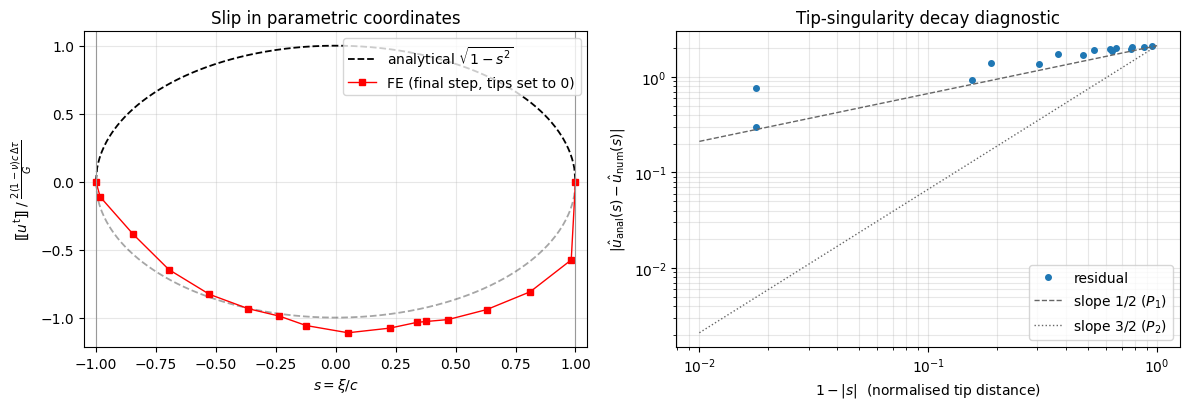

slip_max  analytical (phys) = 2.2346e-03
slip_max  FE          (phys)= -2.4844e-03   (centre, s ~ 0)
FE tip slip  |s| -> 1       = -2.5079e-04, -1.2870e-03   (should be 0 in the analytical limit)

Tip values are NOT expected to be zero in the FE solution because the
nearest jump DOF is one element-edge from the geometric tip, the
sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the
finite box adds a domain correction.  The tip-decay log-log slope on
the right panel is the diagnostic: P1 elements should give slope 1/2,
P2 should give slope 3/2; departures indicate cone-tolerance noise or
BOX_SCALE-induced finite-domain bias.
Pollard L2 (interior |s|<0.95): err=9.222e-04 m, ref=6.972e-03 m, rel=0.132


In [22]:
# =============================================================================
# Slip profile vs Crouch-Starfield / Pollard-Segall analytical
# =============================================================================
# Numerical:   stored in DOF order, NOT arclength order — must be sorted by
#              actual contact-node coordinates (poro_s._nodal_interface_info).
# Analytical:  hat_u(s) = sqrt(1 - s^2), s = xi / c.
# Tip closure: outermost FE jump DOFs sit one element-edge inside the geometric
#              tip; the geometric tip itself has [[u_t]] = 0, so we explicitly
#              prepend / append (s = ±1, slip = 0).
# =============================================================================

# Analytical scale (was previously computed in a deleted preamble cell)
crack_half_length = CRACK_LENGTH / 2.0
delta_tau_mpa     = abs(tau_sliding_val) - MU * sigma_N_sliding

c_half        = crack_half_length
slip_max_anal = 2.0 * delta_tau_mpa * (1.0 - NU) * c_half / G_SHEAR
DISP_SCALE    = SCALE_L * SCALE_EPS
print(f"Analytical max slip (physical units) = {slip_max_anal:.4e}  (applied scale {DISP_SCALE:.1e})")

# --- Sort numerical slip by actual tangent coordinate along the crack -------
# Works for conforming AND SBM meshes: SBM surrogate nodes are off the true
# crack but their projection onto the principal axis still gives a valid
# arclength ordering.
slip_phys = np.asarray(sliding_slip[-1], dtype=float) * DISP_SCALE
n_nodes   = slip_phys.size

_contact_coords = np.asarray(
    poro_s._nodal_interface_info["lambda_coords"], dtype=float
)  # shape (dim, n_c)
_centered = _contact_coords - _contact_coords.mean(axis=1, keepdims=True)
_axis     = np.linalg.svd(_centered, full_matrices=False)[0][:, 0]
_xi_raw   = _axis @ _contact_coords
xi_phys   = _xi_raw - 0.5 * (_xi_raw.min() + _xi_raw.max())

_sort_order = np.argsort(xi_phys)
xi_phys     = xi_phys[_sort_order]
slip_phys   = slip_phys[_sort_order]
s_param     = xi_phys / c_half

# --- Augment with geometric-tip zero values --------------------------------
xi_with_tips      = np.concatenate(([-c_half], xi_phys, [c_half]))
slip_with_tips    = np.concatenate(([0.0],     slip_phys, [0.0]))
s_param_with_tips = xi_with_tips / c_half

print(f"FE jump-DOF coverage: outermost |s| = {np.max(np.abs(s_param)):.4f} "
      f"(closest jump DOF to tip), tips at |s| = 1 set to 0 explicitly")

# Normalised numerical and analytical slip
slip_norm_num   = slip_phys / slip_max_anal
slip_norm_anal  = np.sqrt(np.clip(1.0 - s_param ** 2, 0.0, None))

# --- Plot: parametric profile + tip-decay diagnostic ------------------------
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.2))

s_dense = np.linspace(-1, 1, 401)
ax_left.plot(s_dense, np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3,
             label=r'analytical $\sqrt{1-s^2}$')
ax_left.plot(s_dense, -np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3, alpha=0.35)
slip_norm_num_with_tips = slip_with_tips / slip_max_anal
ax_left.plot(s_param_with_tips, slip_norm_num_with_tips, 'rs-', ms=4, lw=1.0,
             label='FE (final step, tips set to 0)')
ax_left.set_xlabel(r'$s = \xi / c$')
ax_left.set_ylabel(r'$[\![u^{\rm t}]\!] \; / \; \frac{2(1-\nu)c\,\Delta\tau}{G}$')
ax_left.set_title('Slip in parametric coordinates')
ax_left.set_xlim(-1.05, 1.05)
ax_left.axvline(-1, color='0.6', lw=0.8); ax_left.axvline(1, color='0.6', lw=0.8)
ax_left.legend(loc='upper right')
ax_left.grid(alpha=0.3)

tip_dist  = 1.0 - np.abs(s_param)
err       = np.abs(slip_norm_anal - slip_norm_num)
mask      = (tip_dist > 0) & (err > 0)
ax_right.loglog(tip_dist[mask], err[mask], 'o', ms=4, label='residual')
ref_x = np.array([1e-2, 1.0])
ref_y_p1 = err[mask].max() * (ref_x / ref_x.max()) ** 0.5
ref_y_p2 = err[mask].max() * (ref_x / ref_x.max()) ** 1.5
ax_right.loglog(ref_x, ref_y_p1, '--', color='0.4', lw=1.0,
                label=r'slope $1/2$ ($P_1$)')
ax_right.loglog(ref_x, ref_y_p2, ':',  color='0.4', lw=1.0,
                label=r'slope $3/2$ ($P_2$)')
ax_right.set_xlabel(r'$1 - |s|$  (normalised tip distance)')
ax_right.set_ylabel(r'$|\hat u_{\rm anal}(s) - \hat u_{\rm num}(s)|$')
ax_right.set_title('Tip-singularity decay diagnostic')
ax_right.legend(loc='lower right')
ax_right.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# --- Reporter ---
print(f"slip_max  analytical (phys) = {slip_max_anal:.4e}")
print(f"slip_max  FE          (phys)= {slip_phys[np.argmin(np.abs(s_param))]:.4e}"
      f"   (centre, s ~ 0)")
print(f"FE tip slip  |s| -> 1       = {slip_phys[0]:.4e}, {slip_phys[-1]:.4e}"
      f"   (should be 0 in the analytical limit)")
print()
print("Tip values are NOT expected to be zero in the FE solution because the")
print("nearest jump DOF is one element-edge from the geometric tip, the")
print("sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the")
print("finite box adds a domain correction.  The tip-decay log-log slope on")
print("the right panel is the diagnostic: P1 elements should give slope 1/2,")
print("P2 should give slope 3/2; departures indicate cone-tolerance noise or")
print("BOX_SCALE-induced finite-domain bias.")

slip_anal_phys = slip_max_anal * slip_norm_anal
mask_interior  = np.abs(s_param) < 0.95
err_l2 = float(np.linalg.norm(np.abs(slip_phys[mask_interior]) - np.abs(slip_anal_phys[mask_interior])))
ref_l2 = float(np.linalg.norm(np.abs(slip_anal_phys[mask_interior])))
print(f"Pollard L2 (interior |s|<0.95): err={err_l2:.3e} m, ref={ref_l2:.3e} m, "
      f"rel={err_l2 / max(ref_l2, 1e-30):.3f}")

### 10d. Energy Balance Check

For the perturbation formulation with $\alpha = 0$ and roller BCs, the bulk power
identity reads
$$\frac{d}{dt}\bigl(\text{KE} + U_\text{el}\bigr) + D_\text{vis,rate}
   = \bigl(B\,r_\text{total}\bigr)\cdot v,$$
where $D_\text{vis,rate} = v^\top C\,v$ is the bulk Kelvin-Voigt dissipation rate
and the right-hand side is the power exerted by the contact reactions on the
bulk velocity.  Integrating gives
$$\text{KE}(t) + U_\text{el}(t) + D_\text{vis}(t) - W_\text{contact}(t) \approx 0.$$

A **growing** residual is a numerical-conservation diagnostic: at fixed material
parameters, larger residual at higher viscosity points to under-resolved
time-stepping (e.g. controller skipping the contact block, $h_{\max}$ too large).


Energy balance (sliding test):
  final KE                       = 4.145e-07   (≈ 0 expected at QS)
  final W_el                     = 8.708e-01   (cumulative bulk elastic work)
  final D_vis (incl. Lysmer)     = 9.127e-01   (bulk viscous + boundary dashpot, both in C_op)
  final D_fric (phys)            = 2.481e+00   (Coulomb interface dissipation)
  final D_lysmer (boundary)      = 7.287e-01   (Lysmer dashpot energy out)

  final W_contact     (r_total)  = -3.769e+00   (sum of pert + offset)
  final W_contact_pert(r_pert )  = 1.784e+00   (what BULK eqn integrates)
  final W_offset_external        = -5.553e+00   (prestress reservoir)

  Bulk identity (rigorous, uses r_pert)         : 3.074e-04   (rel: 1.723e-04)
    KE + W_el + D_vis − W_contact_pert ≈ 0
  Bulk identity (loose, uses r_total)           : 5.553e+00   (rel: 1.473e+00)
    KE + W_el + D_vis − W_contact_total ≈ 0  (off by W_offset_external)
  Interface identity (Coulomb, r_total)         : 1.288e+00   (rel: 3.418e-01)
    D

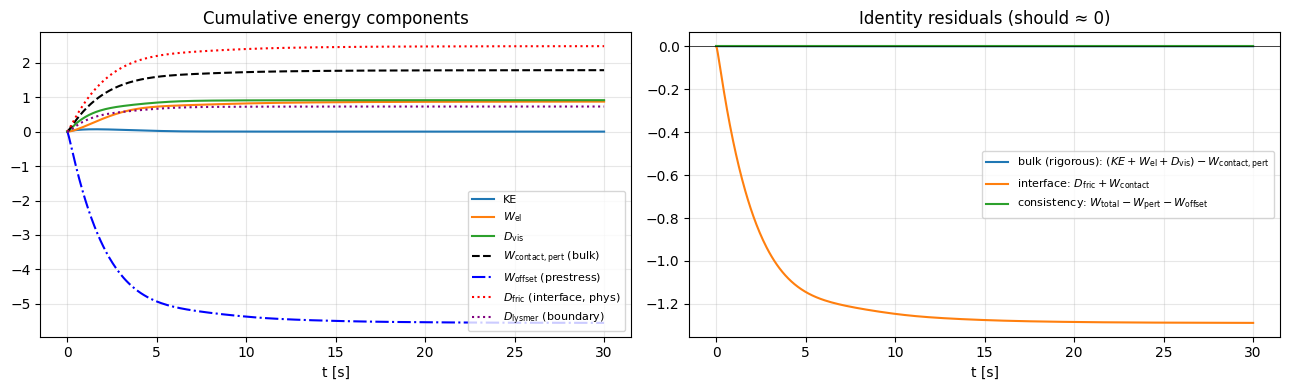

In [23]:
y_hist_s = np.asarray(y_sliding, dtype=float)
t_arr_s  = np.asarray(t_sliding, dtype=float)

# ── Operators in the descriptor frame ──────────────────────────────────────
J0 = rhs_jac_dyn_s_eff(0.0, np.zeros(A_dyn_s.shape[0])).tocsr()
A0 = A_dyn_s.tocsr()

mom_rows  = slice(n_base_s, n_phys_sliding)
base_cols = slice(0, n_base_s)
vel_cols  = slice(n_base_s, n_phys_sliding)

# All extracted from the descriptor Jacobian / mass; signs match the
# convention   M v̇ = -K z - C v + B r  +  prestress.
K_op = -(J0[mom_rows, :][:, base_cols]).tocsr()   # rotated-frame stiffness
C_op = -(J0[mom_rows, :][:, vel_cols]).tocsr()    # viscous tangent
M_op = (A0[mom_rows, :][:, vel_cols]).tocsr()     # FE mass

# ── State histories ─────────────────────────────────────────────────────────
z_hist      = y_hist_s[:, :n_base_s]
v_hist      = y_hist_s[:, n_base_s:n_phys_sliding]
r_pert_hist = y_hist_s[:, n_phys_sliding:]
sigma_offset_nondim = _contact_offset_vector(_s0_val_s, _w0_val_s)
r_total_hist = r_pert_hist + sigma_offset_nondim[None, :]

B_vel = B_c_dyn_s[n_base_s:n_phys_sliding, :].tocsr()

# Interface weights ω_k per contact node (the lumped FE measure)
omega_node = np.asarray(omega_n_s if 'omega_n_s' in globals() else omega_n, dtype=float)

# r_pert is interleaved [r_n_0, r_t_0, r_n_1, r_t_1, …]
r_n_pert_hist = r_pert_hist[:, 0::2]
r_t_pert_hist = r_pert_hist[:, 1::2]
r_n_total_hist_nd = r_n_pert_hist + _s0_val_s[None, :]
r_t_total_hist_nd = r_t_pert_hist + _w0_val_s[None, :]

# ── Storage convention: r_stored ≡ [[λ_σ]] = 2 · r_phys ────────────────────
# Per the variational two-sided trace:
#       [[σ]]·n̂ = 2 {{t̂}}      (jump of σ·n̂ equals twice the avg phys traction)
# The Coulomb cone is scale-invariant, so r_stored is consistent for the
# constraint, but for an explicit interface dissipation in physical units
# we apply r_phys = (1/2) r_stored.
HALF_PHYS = 0.5

# ── Per-step instantaneous power rates (nondim) ────────────────────────────
n_steps = len(t_arr_s)
KE          = np.zeros(n_steps)
P_elastic   = np.zeros(n_steps)   # rate of bulk elastic work: v · K_op · z
D_vis_rate  = np.zeros(n_steps)
P_contact         = np.zeros(n_steps)   # uses r_total (offset + pert)
P_contact_pert    = np.zeros(n_steps)   # uses r_pert  (what bulk actually sees in rhs)
P_offset_external = np.zeros(n_steps)   # uses constant sigma_offset (prestress reservoir)
D_fric_rate       = np.zeros(n_steps)
B_vel_offset = (B_vel @ sigma_offset_nondim)  # constant in time

sliding_vt_arr = np.asarray(sliding_vt, dtype=float)

for k in range(n_steps):
    z_k = z_hist[k]
    v_k = v_hist[k]
    KE[k]          = 0.5 * float(v_k @ (M_op @ v_k))
    P_elastic[k]   = float(v_k @ (K_op @ z_k))
    D_vis_rate[k]  = float(v_k @ (C_op @ v_k))
    P_contact[k]   = float(v_k @ (B_vel @ r_total_hist[k]))
    P_contact_pert[k]    = float(v_k @ (B_vel @ r_pert_hist[k]))
    P_offset_external[k] = float(v_k @ B_vel_offset)
    sigma_N_phys_nd = HALF_PHYS * np.maximum(r_n_total_hist_nd[k], 0.0)
    D_fric_rate[k] = float(np.sum(MU * sigma_N_phys_nd * np.abs(sliding_vt_arr[k]) * omega_node))

D_lysmer_rate = np.zeros(n_steps)
_have_lysmer = '_C_lysmer_sliding' in globals() and _C_lysmer_sliding is not None
if _have_lysmer:
    C_lysmer_vv = _C_lysmer_sliding[mom_rows, :][:, vel_cols].tocsr()
    for k in range(n_steps):
        v_k = v_hist[k]
        D_lysmer_rate[k] = float(v_k @ (C_lysmer_vv @ v_k))

# ── Cumulative integrals (trapezoidal) ──────────────────────────────────────
W_el              = np.zeros(n_steps)   # ∫ v · K_op z dτ  (bulk elastic work)
D_vis_int         = np.zeros(n_steps)
W_contact         = np.zeros(n_steps)   # ∫ v · B · r_total dτ
W_contact_pert    = np.zeros(n_steps)   # ∫ v · B · r_pert  dτ  (what bulk eqn integrates)
W_offset_external = np.zeros(n_steps)   # ∫ v · B · σ_offset dτ (prestress reservoir)
D_fric_int        = np.zeros(n_steps)
for k in range(1, n_steps):
    dt_k = t_arr_s[k] - t_arr_s[k-1]
    W_el[k]       = W_el[k-1]       + 0.5 * (P_elastic[k]   + P_elastic[k-1])   * dt_k
    D_vis_int[k]  = D_vis_int[k-1]  + 0.5 * (D_vis_rate[k]  + D_vis_rate[k-1])  * dt_k
    W_contact[k]  = W_contact[k-1]  + 0.5 * (P_contact[k]   + P_contact[k-1])   * dt_k
    W_contact_pert[k]    = W_contact_pert[k-1]    + 0.5 * (P_contact_pert[k]    + P_contact_pert[k-1])    * dt_k
    W_offset_external[k] = W_offset_external[k-1] + 0.5 * (P_offset_external[k] + P_offset_external[k-1]) * dt_k
    D_fric_int[k] = D_fric_int[k-1] + 0.5 * (D_fric_rate[k] + D_fric_rate[k-1]) * dt_k

D_lysmer_int = np.zeros(n_steps)
for k in range(1, n_steps):
    dt_k = t_arr_s[k] - t_arr_s[k-1]
    D_lysmer_int[k] = D_lysmer_int[k-1] + 0.5 * (D_lysmer_rate[k] + D_lysmer_rate[k-1]) * dt_k

# ── Identities ─────────────────────────────────────────────────────────────
# Bulk power balance (exact in continuous time, descriptor frame):
#     d(KE)/dt = -P_elastic - D_vis_rate + P_contact
#     ⇒  KE(t) + W_el(t) + D_vis(t) - W_contact(t) ≈ 0
#
# Interface Coulomb identity (cone-active, per-area physical units):
#     D_fric(t) + W_contact(t) ≈ 0
# Rigorous bulk identity: bulk only sees B·r_pert in its rhs
res_bulk_pert  = (KE + W_el + D_vis_int) - W_contact_pert
# "Loose" form using r_total (mixes interface friction + offset reservoir)
res_bulk_total = (KE + W_el + D_vis_int) - W_contact
# Interface (Coulomb at active sliding, total reaction)
res_interface  = D_fric_int + W_contact
# Consistency (algebra): W_contact_total = W_contact_pert + W_offset_external
res_consistency = W_contact - (W_contact_pert + W_offset_external)

peak_w_total = max(float(np.max(np.abs(W_contact))), 1e-30)
peak_w_pert  = max(float(np.max(np.abs(W_contact_pert))), 1e-30)
peak_w_off   = max(float(np.max(np.abs(W_offset_external))), 1e-30)
peak_res_bulk_pert  = float(np.max(np.abs(res_bulk_pert)))
peak_res_bulk_total = float(np.max(np.abs(res_bulk_total)))
peak_res_int        = float(np.max(np.abs(res_interface)))
peak_res_consist    = float(np.max(np.abs(res_consistency)))

print("Energy balance (sliding test):")
print(f"  final KE                       = {KE[-1]:.3e}   (≈ 0 expected at QS)")
print(f"  final W_el                     = {W_el[-1]:.3e}   (cumulative bulk elastic work)")
print(f"  final D_vis (incl. Lysmer)     = {D_vis_int[-1]:.3e}   (bulk viscous + boundary dashpot, both in C_op)")
print(f"  final D_fric (phys)            = {D_fric_int[-1]:.3e}   (Coulomb interface dissipation)")
print(f"  final D_lysmer (boundary)      = {D_lysmer_int[-1]:.3e}   (Lysmer dashpot energy out)")
print()
print(f"  final W_contact     (r_total)  = {W_contact[-1]:.3e}   (sum of pert + offset)")
print(f"  final W_contact_pert(r_pert )  = {W_contact_pert[-1]:.3e}   (what BULK eqn integrates)")
print(f"  final W_offset_external        = {W_offset_external[-1]:.3e}   (prestress reservoir)")
print()
print(f"  Bulk identity (rigorous, uses r_pert)         : {peak_res_bulk_pert:.3e}   (rel: {peak_res_bulk_pert/peak_w_pert:.3e})")
print(f"    KE + W_el + D_vis − W_contact_pert ≈ 0")
print(f"  Bulk identity (loose, uses r_total)           : {peak_res_bulk_total:.3e}   (rel: {peak_res_bulk_total/peak_w_total:.3e})")
print(f"    KE + W_el + D_vis − W_contact_total ≈ 0  (off by W_offset_external)")
print(f"  Interface identity (Coulomb, r_total)         : {peak_res_int:.3e}   (rel: {peak_res_int/peak_w_total:.3e})")
print(f"    D_fric + W_contact_total ≈ 0")
print(f"  Algebraic consistency W_total = W_pert + W_off: {peak_res_consist:.3e}   (rel: {peak_res_consist/peak_w_total:.3e})")
print()
print(f"  Interpretation:")
print(f"    The OFFSET (s0,w0 outside cone) is the prestress reservoir that drives slip.")
print(f"    It enters only the cone constraint, NOT the bulk rhs directly.")
print(f"    Bulk identity uses r_pert (rigorous); interface identity uses r_total.")
print(f"    Energy flow: W_offset_external → cone-projected r_pert → bulk dynamics → friction.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, KE, label='KE')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_el, label=r'$W_\mathrm{el}$')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_vis_int, label=r'$D_\mathrm{vis}$')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_contact_pert, ls='--', color='black',
             label=r'$W_\mathrm{contact, pert}$ (bulk)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_offset_external, ls='-.', color='blue',
             label=r'$W_\mathrm{offset}$ (prestress)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_fric_int, ls=':', color='red',
             label=r'$D_\mathrm{fric}$ (interface, phys)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_lysmer_int, ls=':', color='purple',
             label=r'$D_\mathrm{lysmer}$ (boundary)')
axes[0].set_xlabel('t [s]')
axes[0].set_title('Cumulative energy components')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_bulk_pert,
             label=r'bulk (rigorous): $(KE+W_\mathrm{el}+D_\mathrm{vis}) - W_\mathrm{contact, pert}$')
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_interface,
             label=r'interface: $D_\mathrm{fric} + W_\mathrm{contact}$')
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_consistency,
             label=r'consistency: $W_\mathrm{total} - W_\mathrm{pert} - W_\mathrm{offset}$')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('t [s]')
axes[1].set_title('Identity residuals (should ≈ 0)')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


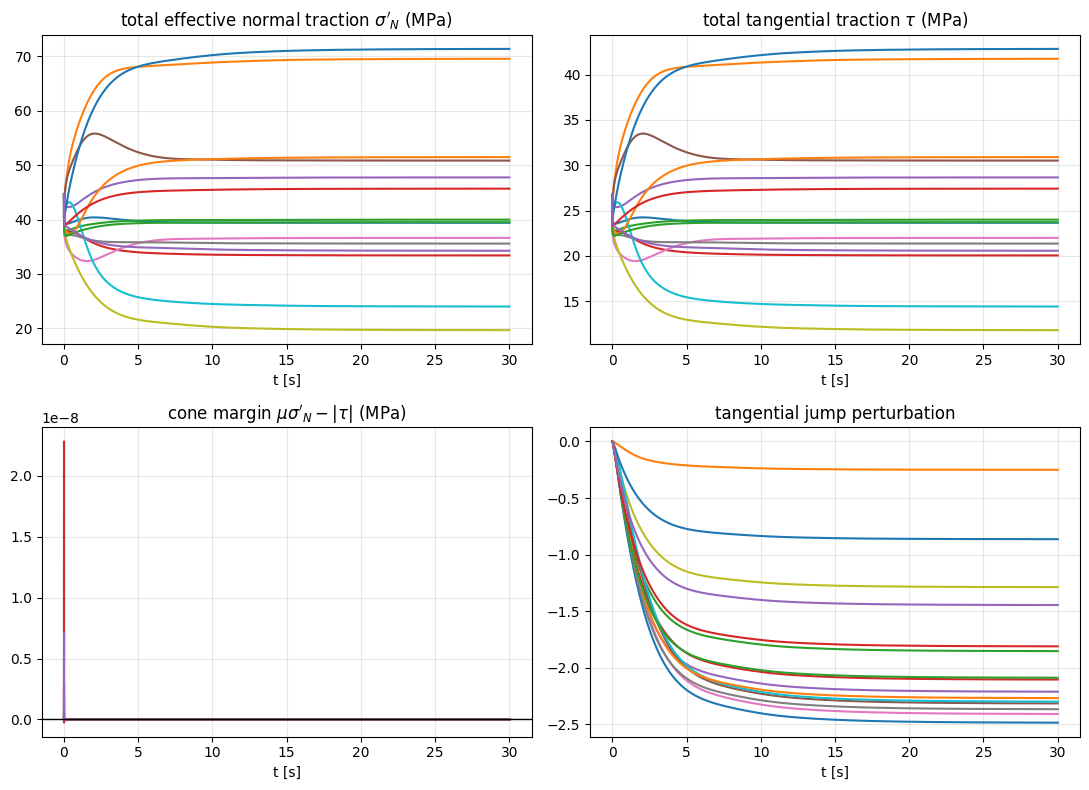

final min cone margin MPa -7.105427357601002e-15
final max |cone margin| MPa 7.105427357601002e-15


In [24]:

# Plot sliding response in physical total effective traction units.
r_n = r_n_sliding
r_t = r_t_sliding
cone_margin = sliding_cone_margin

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(t_sliding * TIME_UNIT_TO_PHYS, r_n)
axes[0,0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
axes[0,0].set_xlabel('t [s]')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(t_sliding * TIME_UNIT_TO_PHYS, r_t)
axes[0,1].set_title(r"total tangential traction $\tau$ (MPa)")
axes[0,1].set_xlabel('t [s]')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(t_sliding * TIME_UNIT_TO_PHYS, cone_margin)
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title(r"cone margin $\mu\sigma'_N-|\tau|$ (MPa)")
axes[1,0].set_xlabel('t [s]')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(t_sliding * TIME_UNIT_TO_PHYS, sliding_slip)
axes[1,1].set_title(r"tangential jump perturbation")
axes[1,1].set_xlabel('t [s]')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("final min cone margin MPa", cone_margin[-1].min())
print("final max |cone margin| MPa", np.max(np.abs(cone_margin[-1])))


### 10aa. Total-stress smoothness across the crack

Variational identity check (rotated nt frame, avg/jmp transform): $[[\sigma_\mathrm{tot}\!\cdot\!n]]$ should be $\approx 0$ (no jump in *total* bulk traction across the crack), and the average $\{\!\{\sigma_\mathrm{tot}\!\cdot\!n\}\!\}$ should equal $\pm R$ (contact reaction). The *effective* traction does jump by $\alpha[[p]]\,n$ via the Biot decomposition — that's separate.


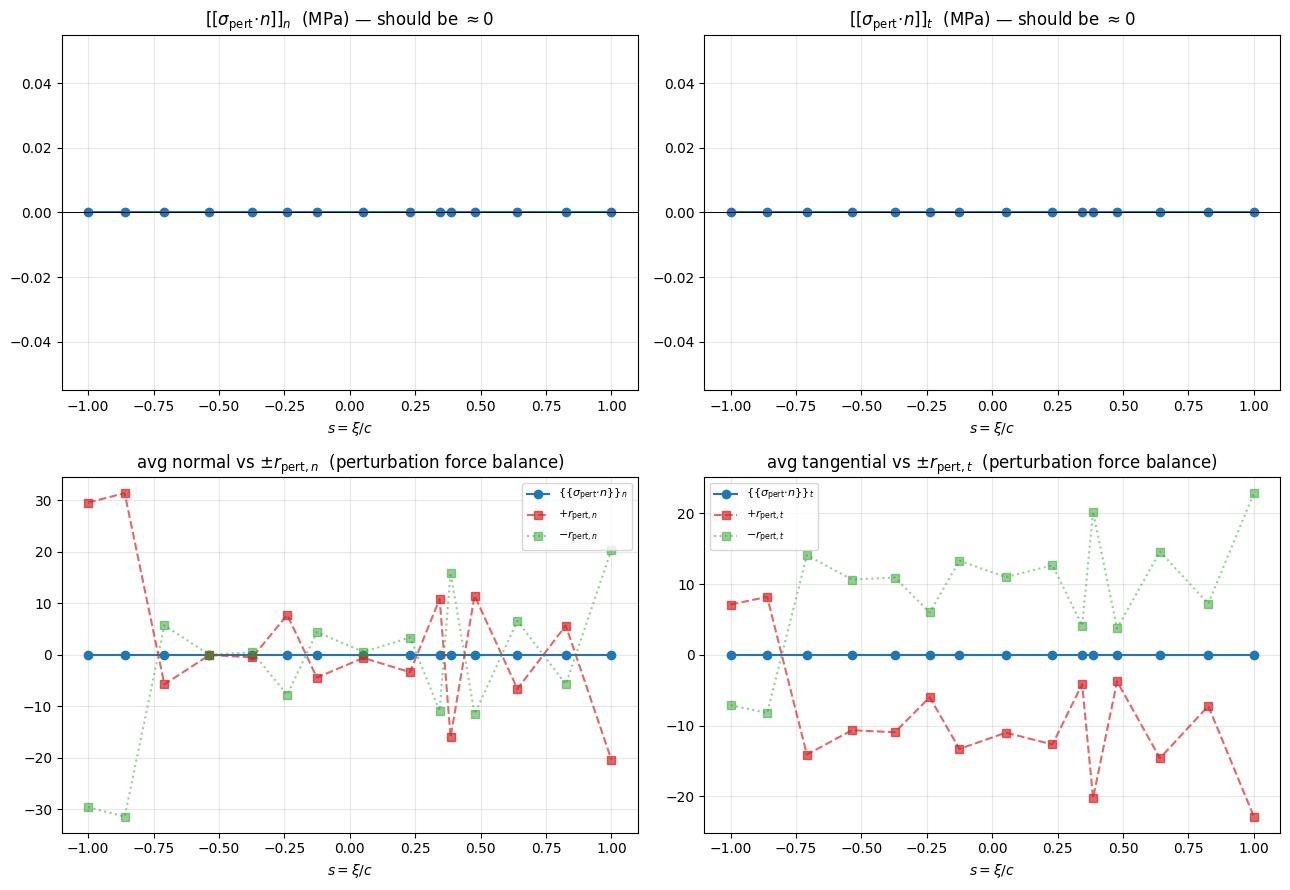

Variational identities (final time):
  max |[[σ_pert·n]]_n|       = 0.000e+00 MPa  (smoothness, expect ~0)
  max |[[σ_pert·n]]_t|       = 0.000e+00 MPa
  max |{{σ_pert·n}}_n − r_pert,n|  = 3.139e+01 MPa
  max |{{σ_pert·n}}_n + r_pert,n|  = 3.139e+01 MPa  (whichever is small ⇒ that's the sign convention)
  max |{{σ_pert·n}}_t − r_pert,t|  = 2.284e+01 MPa
  max |{{σ_pert·n}}_t + r_pert,t|  = 2.284e+01 MPa

For reference: per-side TOTAL effective traction range  R_n: [19.66, 71.39] MPa,  R_t: [11.80, 42.84] MPa
(Total = perturbation + prestress offset; oscillation near tips is the
 1/√r stress singularity unresolvable by P1 basis — the smooth slip
 profile is consistent with this because slip is √r-regular while
 stress is 1/√r-singular.)


In [25]:
# === 10aa. Total-stress smoothness across the crack =========================
# Variational identities for the rotated-nt + avg/jmp σ-multiplier blocks.
#
# Convention (verified from cg_transform.py and cgporoelastostatics.py):
#   λ_σ⁺ and λ_σ⁻ are rotated with the SAME normal n⁺, so each stores
#   σ⁺·n⁺ and σ⁻·n⁺ respectively (consistent-normal, perturbation form).
#   The avg/jmp transform is:
#       avg = ½(λ_σ⁺ + λ_σ⁻),     jmp = λ_σ⁺ − λ_σ⁻
#
# Identities at equilibrium (perturbation form):
#   (1) jmp_lambda_sigma  = [[σ⁻·n⁺]]_pert  ≈  0
#       (traction continuity in the bulk; smoothness)
#   (2) avg_lambda_sigma  =  σ_pert·n⁺
#       (the common per-side perturbation traction, balanced by the
#        perturbation contact reaction r_pert — NOT the total r_total
#        which includes the prestress baseline carried as an offset)
#
# IMPORTANT: avg/jmp blocks and the augmented contact reaction r_pert are
# stored in DOF order, NOT arclength order along the crack.  We sort by the
# actual tangent coordinate before plotting.

info_st = poro_s._transform_info
off_avgls_s = info_st.get('off_avgls', None)
off_jmpls_s = info_st['off_jmpls']

y_final_s = np.asarray(y_sliding[-1], dtype=float)

# Layout (rotated_to_nt + avg/jmp): block-grouped, n then t.
# Each block has n_c_s entries = one value per crack node.
jmp_sigma_n_nondim = y_final_s[off_jmpls_s + 0          : off_jmpls_s + n_c_s    ]
jmp_sigma_t_nondim = y_final_s[off_jmpls_s + n_c_s      : off_jmpls_s + 2 * n_c_s]
jmp_sigma_n_MPa = jmp_sigma_n_nondim * Sigma_scale
jmp_sigma_t_MPa = jmp_sigma_t_nondim * Sigma_scale

if off_avgls_s is not None:
    avg_sigma_n_nondim = y_final_s[off_avgls_s + 0          : off_avgls_s + n_c_s    ]
    avg_sigma_t_nondim = y_final_s[off_avgls_s + n_c_s      : off_avgls_s + 2 * n_c_s]
    avg_sigma_n_MPa = avg_sigma_n_nondim * Sigma_scale
    avg_sigma_t_MPa = avg_sigma_t_nondim * Sigma_scale
else:
    avg_sigma_n_MPa = avg_sigma_t_MPa = None

# Contact reactions (interleaved layout [n0, t0, n1, t1, ...]).
# Both perturbation r_pert (deviation from prestress) and total r_total
# (= r_pert + prestress offset) are computed; the variational identity
# uses r_pert.
r_pert_final_nondim = y_final_s[n_phys_s : n_phys_s + 2 * n_c_s]
offset_final = np.zeros(2 * n_c_s)
offset_final[0::2] = _s0_val_s
offset_final[1::2] = _w0_val_s
r_total_final_nondim = r_pert_final_nondim + offset_final

R_n_MPa     = r_total_final_nondim[0::2] * Sigma_scale   # total per-side σ\'_N
R_t_MPa     = r_total_final_nondim[1::2] * Sigma_scale
rp_n_MPa    = r_pert_final_nondim[0::2]  * Sigma_scale   # perturbation only
rp_t_MPa    = r_pert_final_nondim[1::2]  * Sigma_scale

# --- Sort by actual tangent coordinate along the crack ----------------------
_contact_coords = np.asarray(
    poro_s._nodal_interface_info["lambda_coords"], dtype=float
)  # shape (dim, n_c)
_centered    = _contact_coords - _contact_coords.mean(axis=1, keepdims=True)
_axis        = np.linalg.svd(_centered, full_matrices=False)[0][:, 0]
_xi_raw      = _axis @ _contact_coords
xi_phys      = _xi_raw - 0.5 * (_xi_raw.min() + _xi_raw.max())
_sort_order  = np.argsort(xi_phys)
xi_sorted    = xi_phys[_sort_order]
s_arc        = xi_sorted / max(np.max(np.abs(xi_sorted)), 1e-30)  # normalised to [-1, 1]

jmp_sigma_n_MPa = jmp_sigma_n_MPa[_sort_order]
jmp_sigma_t_MPa = jmp_sigma_t_MPa[_sort_order]
if avg_sigma_n_MPa is not None:
    avg_sigma_n_MPa = avg_sigma_n_MPa[_sort_order]
    avg_sigma_t_MPa = avg_sigma_t_MPa[_sort_order]
R_n_MPa  = R_n_MPa [_sort_order]
R_t_MPa  = R_t_MPa [_sort_order]
rp_n_MPa = rp_n_MPa[_sort_order]
rp_t_MPa = rp_t_MPa[_sort_order]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Top row: jump (smoothness identity) ---
axes[0, 0].plot(s_arc, jmp_sigma_n_MPa, 'o-', color='C0')
axes[0, 0].axhline(0, color='k', lw=0.7)
axes[0, 0].set_title(r'$[[\sigma_\mathrm{pert}\!\cdot\!n]]_n$  (MPa) — should be $\approx 0$')
axes[0, 0].set_xlabel(r'$s = \xi / c$')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(s_arc, jmp_sigma_t_MPa, 'o-', color='C0')
axes[0, 1].axhline(0, color='k', lw=0.7)
axes[0, 1].set_title(r'$[[\sigma_\mathrm{pert}\!\cdot\!n]]_t$  (MPa) — should be $\approx 0$')
axes[0, 1].set_xlabel(r'$s = \xi / c$')
axes[0, 1].grid(alpha=0.3)

# --- Bottom row: avg vs perturbation reaction (force-balance identity) ---
if avg_sigma_n_MPa is not None:
    axes[1, 0].plot(s_arc,  avg_sigma_n_MPa, 'o-',  color='C0',
                    label=r'$\{\{\sigma_\mathrm{pert}\!\cdot\!n\}\}_n$')
    axes[1, 0].plot(s_arc,  rp_n_MPa,        's--', color='C3', alpha=0.7,
                    label=r'$+r_{\mathrm{pert},n}$')
    axes[1, 0].plot(s_arc, -rp_n_MPa,        's:',  color='C2', alpha=0.5,
                    label=r'$-r_{\mathrm{pert},n}$')
else:
    axes[1, 0].plot(s_arc, rp_n_MPa, 's-', label=r'$r_{\mathrm{pert},n}$')
axes[1, 0].set_title(r'avg normal vs $\pm r_{\mathrm{pert},n}$  (perturbation force balance)')
axes[1, 0].set_xlabel(r'$s = \xi / c$')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

if avg_sigma_t_MPa is not None:
    axes[1, 1].plot(s_arc,  avg_sigma_t_MPa, 'o-',  color='C0',
                    label=r'$\{\{\sigma_\mathrm{pert}\!\cdot\!n\}\}_t$')
    axes[1, 1].plot(s_arc,  rp_t_MPa,        's--', color='C3', alpha=0.7,
                    label=r'$+r_{\mathrm{pert},t}$')
    axes[1, 1].plot(s_arc, -rp_t_MPa,        's:',  color='C2', alpha=0.5,
                    label=r'$-r_{\mathrm{pert},t}$')
else:
    axes[1, 1].plot(s_arc, rp_t_MPa, 's-', label=r'$r_{\mathrm{pert},t}$')
axes[1, 1].set_title(r'avg tangential vs $\pm r_{\mathrm{pert},t}$  (perturbation force balance)')
axes[1, 1].set_xlabel(r'$s = \xi / c$')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Variational identities (final time):")
print(f"  max |[[σ_pert·n]]_n|       = {np.max(np.abs(jmp_sigma_n_MPa)):.3e} MPa  (smoothness, expect ~0)")
print(f"  max |[[σ_pert·n]]_t|       = {np.max(np.abs(jmp_sigma_t_MPa)):.3e} MPa")
if avg_sigma_n_MPa is not None:
    res_pos_n = np.max(np.abs(avg_sigma_n_MPa - rp_n_MPa))
    res_neg_n = np.max(np.abs(avg_sigma_n_MPa + rp_n_MPa))
    res_pos_t = np.max(np.abs(avg_sigma_t_MPa - rp_t_MPa))
    res_neg_t = np.max(np.abs(avg_sigma_t_MPa + rp_t_MPa))
    print(f"  max |{{{{σ_pert·n}}}}_n − r_pert,n|  = {res_pos_n:.3e} MPa")
    print(f"  max |{{{{σ_pert·n}}}}_n + r_pert,n|  = {res_neg_n:.3e} MPa  (whichever is small ⇒ that\'s the sign convention)")
    print(f"  max |{{{{σ_pert·n}}}}_t − r_pert,t|  = {res_pos_t:.3e} MPa")
    print(f"  max |{{{{σ_pert·n}}}}_t + r_pert,t|  = {res_neg_t:.3e} MPa")
print()
print(f"For reference: per-side TOTAL effective traction range  R_n: "
      f"[{R_n_MPa.min():.2f}, {R_n_MPa.max():.2f}] MPa,  "
      f"R_t: [{R_t_MPa.min():.2f}, {R_t_MPa.max():.2f}] MPa")
print("(Total = perturbation + prestress offset; oscillation near tips is the")
print(" 1/√r stress singularity unresolvable by P1 basis — the smooth slip")
print(" profile is consistent with this because slip is √r-regular while")
print(" stress is 1/√r-singular.)")

### 10a. Dashboard — Sliding

Full-field perturbation contours.  Expect visible displacement discontinuity at the crack
and stress redistribution near the crack tips.

In [26]:
z_sliding = y_sliding[:, :n_base_s]

fields_sliding = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sliding),
    z_sliding.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_sliding['y_raw'] = z_sliding.T
fields_sliding['t_raw'] = np.asarray(t_sliding)

dashboard_sliding = CGPoroelasticDashboard(poro_s, fields_sliding, levels=40)
dashboard_sliding.show()

## 10e. Slip-Weakening Friction Extension

Replace constant μ on the sliding crack by a slip-weakening law:

$$
\mu(s) = \mu_\mathrm{res}\Bigl(1 - \frac{\Delta\mu}{\mu_\mathrm{res}}\,e^{-s_\mathrm{eff}/D_c}\Bigr),
\qquad s_\mathrm{eff} = \max(s, 0),
\qquad \dot s = \lvert [[v_t]]\rvert.
$$

With $\Delta\mu = \mu_\mathrm{res} - \mu_\mathrm{static} = -0.1$ and $\mu_\mathrm{res}=0.5$,
$\mu_\mathrm{static} = 0.6$ and friction monotonically weakens to $\mu_\mathrm{res}$ over
the characteristic slip $D_c = 0.10\,\mathrm{mm}$. Cumulative slip $s$ is added as a new
ODE state per contact node — one extra DOF each, with $\dot s = |[[v_t]]| \ge 0$ enforcing
no healing without any explicit clamp.

**Stability criterion (Ruina/Rice).** Linearised stability of the QS branch requires
$G/D > -\Delta\mu\,\sigma_N/D_c$. When violated, $|[[u_t]]|$ runs away to the stress-drop
seismic slip $\Delta\tau\,D/G = -\Delta\mu\,\sigma_N\,D/G$.


In [27]:
# # === Slip-weakening config and validation diagnostics ====================
# # Slip-weakening parameterised by (μ_static, μ_res):
# #   DMU_SW = μ_res − μ_static  (≤ 0 weakens, 0 ⇒ pure Coulomb at μ_static).
# # Set MU_RES_SW = MU_STATIC_SW for pure Coulomb; MU_RES_SW = 0.5 for weakening.
# MU_STATIC_SW = 0.6                                   # peak (≡ global MU)
# MU_RES_SW    = 0.5                                   # residual (set 0.5 for weakening)
# DMU_SW       = MU_RES_SW - MU_STATIC_SW              # auto: 0 here, −0.1 if μ_res=0.5
# DC_PHYS_SW   = 0.10 / 1000.0                         # m  (0.10 mm)
# DC_NONDIM_SW = DC_PHYS_SW / DISP_SCALE               # state is non-dim displacement

# print(f"Slip-weakening: mu_static={MU_STATIC_SW}, mu_res={MU_RES_SW}, "
#       f"Dmu={DMU_SW:+}")
# print(f"  Dc_phys = {DC_PHYS_SW:.3e} m,   Dc_nondim = {DC_NONDIM_SW:.3e}")

# # --- Stability + seismic-slip estimates (user pseudo-solution) ----------
# G_phys_sw     = G_SHEAR
# D_len_sw      = CRACK_LENGTH                                    # crack length [m]
# L_len_sw      = max(XMAX - XMIN, YMAX - YMIN, 1e-30)            # domain length [m]
# sigma_N_eff_0 = sigma_N_sliding                                 # MPa, far-field

# print(f"  G/(D/L)        = {G_phys_sw / (D_len_sw / L_len_sw):.3e}",
#       f"  -Dmu*sigma_N/Dc = {-DMU_SW * sigma_N_eff_0 / DC_PHYS_SW:.3e}  [units mismatch: see below]")

# # Dimensionally clean form: G/D (MPa/m) vs -Δμ σ_N / Dc (MPa/m)
# loading_stiffness_per_m  = G_phys_sw / D_len_sw
# weakening_rate_per_m     = -DMU_SW * sigma_N_eff_0 / DC_PHYS_SW
# stable_qs                = loading_stiffness_per_m > weakening_rate_per_m
# print(f"  loading G/D    = {loading_stiffness_per_m:.3e} MPa/m")
# print(f"  -Dmu sigma_N/Dc= {weakening_rate_per_m:.3e} MPa/m")
# print(f"  QS-stable: {stable_qs}")

# EQslip = -G_phys_sw / (D_len_sw / L_len_sw) > DMU_SW * sigma_N_eff_0 / DC_PHYS_SW
# print(f"  EQ-like slip predicted (user form): {EQslip}")

# expd_slip_per_L = -DMU_SW * sigma_N_eff_0 / G_phys_sw * D_len_sw / L_len_sw
# expd_slip_phys  = expd_slip_per_L * L_len_sw           # = -Dmu * sigma_N * D / G  [m]
# print(f"  Expected stress-drop seismic slip [m] (-Dmu sigma_N D / G): {expd_slip_phys:.3e}")

# # === State augmentation: append cumulative slip s_k per contact node =====
# n_phys_old_sw = n_phys_s
# n_aug_sw      = n_phys_old_sw + n_c_s

# A_aug_sw = sp.block_diag(
#     [A_dyn_s, sp.eye(n_c_s, format='csr')], format='csr',
# )

# # v_t extraction: rows n_c..2n_c of vel_extract_dyn_s pick [[v_t]] (grouped order).
# vel_t_extract_sw = vel_extract_dyn_s[n_c_s:2 * n_c_s, :].tocsr()

# def rhs_sw(t, y, *extra):
#     y_phys = y[:n_phys_old_sw]
#     out = np.zeros(n_aug_sw)
#     out[:n_phys_old_sw] = rhs_dyn_s_eff(t, y_phys)
#     out[n_phys_old_sw:] = np.abs(vel_t_extract_sw @ y_phys)
#     return out

# def rhs_jac_sw(t, y, *extra):
#     y_phys = y[:n_phys_old_sw]
#     J_phys = rhs_jac_dyn_s_eff(t, y_phys)
#     if not sp.issparse(J_phys):
#         J_phys = sp.csr_matrix(J_phys)
#     v_t = vel_t_extract_sw @ y_phys
#     J_slip = sp.diags(np.sign(v_t)) @ vel_t_extract_sw
#     return sp.bmat(
#         [[J_phys,                                sp.csr_matrix((n_phys_old_sw, n_c_s))],
#          [J_slip,                                sp.csr_matrix((n_c_s,        n_c_s))]],
#         format='csr',
#     )

# # --- Pad contact wiring with zero columns/rows for the new slip block ---
# gap_extract_sw = sp.hstack(
#     [gap_extract_dyn_s, sp.csr_matrix((gap_extract_dyn_s.shape[0], n_c_s))],
#     format='csr',
# )
# vel_extract_sw = sp.hstack(
#     [vel_extract_dyn_s, sp.csr_matrix((vel_extract_dyn_s.shape[0], n_c_s))],
#     format='csr',
# )
# B_c_sw = sp.vstack(
#     [B_c_dyn_s, sp.csr_matrix((n_c_s, B_c_dyn_s.shape[1]))],
#     format='csr',
# )

# # --- Per-contact slip-weakening mu + analytical dmu/dy ------------------
# def _make_mu_sw(k):
#     idx = n_phys_old_sw + k
#     def _mu(y, t=None, Fk_val=None):
#         s_k = float(y[idx])
#         s_eff = s_k if s_k > 0.0 else 0.0
#         return MU_RES_SW * (1.0 - (DMU_SW / MU_RES_SW) * np.exp(-s_eff / DC_NONDIM_SW))
#     return _mu

# def _make_dmu_dy_sw(k):
#     idx = n_phys_old_sw + k
#     def _dmu(y, t=None, Fk_val=None):
#         out = np.zeros(n_aug_sw)
#         s_k = float(y[idx])
#         if s_k > 0.0:
#             out[idx] = (DMU_SW / DC_NONDIM_SW) * np.exp(-s_k / DC_NONDIM_SW)
#         return out
#     return _dmu

# contacts_sw = [
#     {
#         'vel_normal_idx': k,
#         'vel_tangential_idx': [n_c_s + k],
#         'mu':     _make_mu_sw(k),
#         'dmu_dy': _make_dmu_dy_sw(k),
#         'e': 0.0,
#     }
#     for k in range(n_c_s)
# ]

# cs_sw = build_projected_radau_contact(
#     A_aug_sw, rhs_sw, np.zeros(n_aug_sw),
#     contacts=contacts_sw,
#     C_extract=gap_extract_sw,
#     D_extract=vel_extract_sw,
#     B=B_c_sw,
#     constraints=[flux_constraint_s, zero_lam_s_s],
#     component_slices=list(comp_slices_s) + [slice(n_phys_old_sw, n_aug_sw)],
#     rhs_jac=rhs_jac_sw,
#     get_s0=get_s0_sliding, get_w0=get_w0_sliding,
#     normal_r='auto', friction_r='auto',
#     endpoint_inactive_handling='natural_map',
#     contact_law=CONTACT_LAW,
#     reported_reaction_units='force',
#     auto_rho_strategy='delassus',
# )
# print(f"slip-weakening contact system: A={cs_sw.A.shape}, |y0|={cs_sw.y0.size}, "
#       f"slip block at [{n_phys_old_sw}:{n_aug_sw}]")


In [28]:
# # === Solve slip-weakening sliding test ===================================
# n_aug_total_sw = cs_sw.y0.size
# nl_atol_sw = np.full(n_aug_total_sw, 1e-8)
# nl_rtol_sw = np.full(n_aug_total_sw, 1e-6)
# # Slip block: tight ODE tolerance, no relative scaling
# nl_atol_sw[n_phys_old_sw:n_aug_sw] = 1e-10
# nl_rtol_sw[n_phys_old_sw:n_aug_sw] = 0.0
# # Reaction block: as in the const-mu sliding solve
# nl_atol_sw[n_aug_sw:] = 1e-10
# nl_rtol_sw[n_aug_sw:] = 0.0

# solver_opts_sw = dict(cs_sw.solver_opts)
# solver_opts_sw.update(
#     tol=1e-8, max_iter=500, rhs_jac=cs_sw.rhs_jac,
#     linear_solver='petsc',
#     petsc_options={'ksp_type': 'preonly', 'pc_type': 'lu',
#                    'pc_factor_mat_solver_type': 'mumps'},
# )
# integrator_opts_sw = dict(cs_sw.integrator_opts)
# integrator_opts_sw.update({'stages': 2, 'use_coupled_newton': True})

# print(f"Solving slip-weakening sliding: tmax={TMAX}, h0={H0_ADAPTIVE}, "
#       f"contact_law={CONTACT_LAW!r}")

# # Warm-start contact reactions onto the Coulomb cone (μ_static at t=0).
# y0_sw_init = cs_sw.y0.copy()
# y0_sw_init[-2 * n_c_s:] = coulomb_cone_warm_start(_s0_val_s, _w0_val_s, MU_STATIC_SW)

# (t_sw, y_sw, h_sw, fk_sw, info_sw, attempts_sw) = solve_nivp.solve_ivp_ns(
#     fun=cs_sw.rhs, t_span=(0, TMAX), y0=y0_sw_init,
#     method='radau_iia', integrator_opts=integrator_opts_sw,
#     projection=cs_sw.projection, solver='semismooth_newton',
#     projection_opts={'component_slices': cs_sw.component_slices},
#     solver_opts=solver_opts_sw,
#     adaptive=True, h0=H0_ADAPTIVE, rtol=ADAPTIVE_RTOL, atol=ADAPTIVE_ATOL,
#     skip_error_indices=[0], active_set_filter=False, return_attempts=True,
#     adaptive_opts=dict(h0=H0_ADAPTIVE, h_min=ADAPTIVE_H_MIN,
#                        h_max=ADAPTIVE_H_MAX, h_up=2.0, h_down=0.5,
#                        method_order=1),
#     nl_atol=nl_atol_sw, nl_rtol=nl_rtol_sw,
#     component_slices=cs_sw.component_slices,
#     verbose=True, A=cs_sw.A, dae_var_weight='auto',
# )
# t_sw = np.asarray(t_sw, dtype=float)
# y_sw = np.asarray(y_sw, dtype=float)

# # --- Post-process: slip, jump, effective mu -----------------------------
# slip_state_sw   = y_sw[:, n_phys_old_sw:n_aug_sw]                # cumulative s_k(t)
# sliding_jump_sw = y_sw[:, jmpu_t_idx_s]                          # signed [[u_t]]
# mu_eff_sw = MU_RES_SW * (
#     1.0 - (DMU_SW / MU_RES_SW)
#     * np.exp(-np.maximum(slip_state_sw, 0.0) / DC_NONDIM_SW)
# )

# slip_max_phys = float(np.max(np.abs(sliding_jump_sw)) * DISP_SCALE)
# s_max_nondim  = float(np.max(slip_state_sw))
# s_max_phys    = s_max_nondim * DISP_SCALE
# print(f"Done: {len(t_sw)} states, t_final = {t_sw[-1]:.3e}")
# print(f"  max cumulative s (phys, m)        = {s_max_phys:.3e}")
# print(f"  max |[[u_t]]| (phys, m)           = {slip_max_phys:.3e}")
# print(f"  mu observed                       = "
#       f"[{mu_eff_sw.min():.4f}, {mu_eff_sw.max():.4f}]  "
#       f"(static={MU_STATIC_SW}, res={MU_RES_SW})")
# print(f"  s/Dc reached                      = {s_max_phys / DC_PHYS_SW:.3f}")
# print(f"  slip / expected stress-drop slip  = "
#       f"{slip_max_phys / max(expd_slip_phys, 1e-30):.3f}")


In [29]:
# # === Plot slip-weakening response ========================================
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# axes[0, 0].plot(t_sw, slip_state_sw * DISP_SCALE)
# axes[0, 0].axhline(DC_PHYS_SW, color='r', ls='--', alpha=0.6, label=r'$D_c$')
# axes[0, 0].set_title(r'cumulative slip $s_k(t)$ (m)')
# axes[0, 0].set_xlabel('t [s]')
# axes[0, 0].set_ylabel('m')
# axes[0, 0].legend()
# axes[0, 0].grid(alpha=0.3)

# axes[0, 1].plot(t_sw, mu_eff_sw)
# axes[0, 1].axhline(MU_STATIC_SW, color='k', ls=':', alpha=0.6,
#                    label=fr'$\mu_\mathrm{{static}}={MU_STATIC_SW}$')
# axes[0, 1].axhline(MU_RES_SW, color='r', ls=':', alpha=0.6,
#                    label=fr'$\mu_\mathrm{{res}}={MU_RES_SW}$')
# axes[0, 1].set_title(r'effective $\mu(s_k)$')
# axes[0, 1].set_xlabel('t [s]')
# axes[0, 1].legend()
# axes[0, 1].grid(alpha=0.3)

# axes[1, 0].plot(t_sw, sliding_jump_sw * DISP_SCALE)
# axes[1, 0].axhline(expd_slip_phys, color='r', ls='--', alpha=0.6,
#                    label=r'$+\Delta\tau D/G$')
# axes[1, 0].axhline(-expd_slip_phys, color='r', ls='--', alpha=0.6)
# axes[1, 0].set_title(r'tangential jump $[[u_t]]$ (m)')
# axes[1, 0].set_xlabel('t [s]')
# axes[1, 0].legend()
# axes[1, 0].grid(alpha=0.3)

# axes[1, 1].semilogy(t_sw[1:], np.diff(t_sw))
# axes[1, 1].set_title('step size')
# axes[1, 1].set_xlabel('t [s]')
# axes[1, 1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

# print("Validation summary (slip-weakening):")
# print(f"  QS-stable predicted:                 {stable_qs}  (G/D vs -Δμ σ_N/Dc)")
# print(f"  EQ-like slip predicted (user form):  {EQslip}")
# print(f"  numerical max |[[u_t]]| / expected:  "
#       f"{slip_max_phys / max(expd_slip_phys, 1e-30):.3f}")
# print(f"  mu reached residual?                 "
#       f"{abs(mu_eff_sw.min() - MU_RES_SW) < 1e-3}")


In [30]:
# # === Slip-weakening: dimensional traction / cone-margin / slip plots ====
# r_pert_sw, r_total_sw_nd, r_n_sw_nd, r_t_sw_nd = _contact_history(
#     y_sw, n_aug_sw, n_c_s, _s0_val_s, _w0_val_s,
# )
# r_n_sw = r_n_sw_nd * Sigma_scale                              # MPa, σ'_N
# r_t_sw = r_t_sw_nd * Sigma_scale                              # MPa, τ
# cone_margin_sw = mu_eff_sw * r_n_sw - np.abs(r_t_sw)          # MPa, μ(s)σ'_N − |τ|

# fig, axes = plt.subplots(2, 2, figsize=(11, 8))
# axes[0, 0].plot(t_sw, r_n_sw)
# axes[0, 0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
# axes[0, 0].set_xlabel('t [s]'); axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(t_sw, r_t_sw)
# axes[0, 1].set_title(r"total tangential traction $\tau$ (MPa)")
# axes[0, 1].set_xlabel('t [s]'); axes[0, 1].grid(True, alpha=0.3)

# axes[1, 0].plot(t_sw, cone_margin_sw)
# axes[1, 0].axhline(0, color='k', lw=1)
# axes[1, 0].set_title(r"cone margin $\mu(s)\sigma'_N - |\tau|$ (MPa)")
# axes[1, 0].set_xlabel('t [s]'); axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].plot(t_sw, sliding_jump_sw * DISP_SCALE)
# axes[1, 1].set_title(r"tangential jump $[[u_t]]$ (m)")
# axes[1, 1].set_xlabel('t [s]'); axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()
# print(f"final min cone margin MPa: {cone_margin_sw[-1].min():.6e}")
# print(f"final max |cone margin| MPa: {np.max(np.abs(cone_margin_sw[-1])):.6e}")


In [31]:
# # === Slip-weakening: dimensional full-field dashboard ===================
# _taylor_order_sw = 2 if poro_s.include_hessian else 1
# z_sw = y_sw[:, :n_base_s]

# fields_sw = poro_s.sol_to_fields_dict_with_dimensions(
#     np.asarray(t_sw), z_sw.T,
#     use_taylor_correction=True,
#     taylor_order=_taylor_order_sw,
#     constrained_l2=False,
# )
# fields_sw['y_raw'] = z_sw.T
# fields_sw['t_raw'] = np.asarray(t_sw)
# print(f"Fields extracted ({len(fields_sw)} keys, taylor_order={_taylor_order_sw})")

# dashboard_sw = CGPoroelasticDashboard(poro_s, fields_sw, levels=40)
# dashboard_sw.show()


## 11. Injection-induced fault reactivation

Marginally stable fault driven into slip by an off-fault compact pressure
source.  The fault sits inside the Mohr-Coulomb cone under the existing
prestress (resolved shear $|\tau| < \mu\sigma_N$).  A Wendland $C^{2}$
injection source placed close to one tip raises the effective pore
pressure on the fault, dropping $\sigma_N - \{\!\{p\}\!\}$ until the
Coulomb criterion is breached and the slip patch grows along the fault
from the loaded tip outward (Garagash &amp; Germanovich 2012; Bhattacharya &amp;
Viesca 2019, sealed-fault marginally-pressurised regime).

Configuration:
* domain $60 \times 30$ m, fault length $L_f = 20$ m centred at
  $(30,15)$, oriented at $\theta_{\rm Mohr}=35^{\circ}$ — locked margin
  $|\tau|/\mu\sigma_N \approx 0.85$, critical overpressure
  $\Delta p_c = \sigma_N - |\tau|/\mu \approx 5.5$ MPa;
* sealed fault `T_Robin = 0` and `tangential_flow=False` — pressure
  diffuses through the bulk, not across the fault;
* compact Wendland source at $(20.1,11.7)$, $\sim 3$ m perpendicular
  off the lower-left tip, support radius $\sim 1$ m so the source
  footprint never crosses the fault;
* rate-controlled injection $q(t) = q_{\max} \tanh(t/\tau_{\rm ramp})$
  with $\tau_{\rm ramp}=5$ s — smooth start avoids exciting the wave
  clock;
* TMAX = 150 s — five times the prestress ramp window, gives the
  pressure pulse room to traverse the fault and the slip patch room
  to grow.

All other settings (`ALPHA_BIOT`, wave-clock override, Lysmer absorbing
boundary, Mohr-Coulomb constant friction, projected Radau IIA $s=2$)
are inherited from the configuration cells above.


In [32]:
# # --- Domain and fault geometry (PHYSICAL units, m) -----------------------
# XMIN_INJ, XMAX_INJ = 0.0, 60.0
# YMIN_INJ, YMAX_INJ = 0.0, 30.0
# N_ELEM_INJ        = 40

# CRACK_LENGTH_INJ  = 20.0
# CRACK_X0_INJ      = 0.5 * (XMIN_INJ + XMAX_INJ)
# CRACK_Y0_INJ      = 0.5 * (YMIN_INJ + YMAX_INJ)

# # Marginally stable orientation: theta_Mohr = 35 deg => CRACK_THETA = 55 deg
# THETA_MARGINAL    = np.radians(35.0)
# CRACK_THETA_INJ   = np.pi / 2 - THETA_MARGINAL

# sigma_N_inj_phys, tau_inj_phys = mohr_tractions(THETA_MARGINAL)
# delta_p_crit_phys = sigma_N_inj_phys - abs(tau_inj_phys) / MU
# _locked_ratio = abs(tau_inj_phys) / (MU * sigma_N_inj_phys)
# print(f"theta_Mohr = {np.degrees(THETA_MARGINAL):.1f} deg, "
#       f"crack_theta = {np.degrees(CRACK_THETA_INJ):.1f} deg")
# print(f"sigma_N = {sigma_N_inj_phys:.2f} MPa, tau = {tau_inj_phys:.2f} MPa, "
#       f"|tau|/(mu sigma_N) = {_locked_ratio:.3f}  (locked)")
# print(f"critical overpressure Delta p_c = {delta_p_crit_phys:.3f} MPa")

# # --- Fault tip locations (used to place the well) ------------------------
# _t_inj = np.array([np.sin(CRACK_THETA_INJ), np.cos(CRACK_THETA_INJ)])
# _n_inj = np.array([-np.cos(CRACK_THETA_INJ), np.sin(CRACK_THETA_INJ)])
# TIP_LO_INJ = np.array([CRACK_X0_INJ, CRACK_Y0_INJ]) - 0.5 * CRACK_LENGTH_INJ * _t_inj
# TIP_HI_INJ = np.array([CRACK_X0_INJ, CRACK_Y0_INJ]) + 0.5 * CRACK_LENGTH_INJ * _t_inj

# # Well: 3 m perpendicular off the lower-left tip
# # Close to the upper-right tip; offset must exceed SOURCE_R_PHYS so the
# # Wendland support stays one-sided, and >= h/2 so the source is mesh-resolvable.
# WELL_OFFSET_PHYS  = 0.5
# WELL_LOC_PHYS     = TIP_HI_INJ + WELL_OFFSET_PHYS * _n_inj
# POINT_SOURCE_LOC_INJ = np.array([WELL_LOC_PHYS])  # (1,2) physical metres

# # Compact source: physical radius ~ 1 m  (R = 2 sigma = 2 * sources_RMS_width * char_length)
# _char_len_inj = max(XMAX_INJ - XMIN_INJ, YMAX_INJ - YMIN_INJ) / SCALE_L
# SOURCE_R_PHYS         = 0.3   # < WELL_OFFSET_PHYS so support never crosses the fault
# SOURCES_RMS_WIDTH_INJ = SOURCE_R_PHYS / (2.0 * _char_len_inj)

# # --- Injection schedule --------------------------------------------------
# # Rate-controlled tanh ramp.  Q_INJ_PEAK is in dimensional units of an
# # integrated 2D source (volumetric flux, m^2/s); tune to drive {{p}} on
# # the fault past Delta_p_c.  Library normalises Bp so int(Bp_j) = 1.
# Q_INJ_PEAK    = -5.0e1
# TAU_RAMP_INJ  = 5.0       # s

# TMAX_PHYS_INJ = 150.0e-1    # s, ~5x the prestress ramp window
# TMAX_INJ      = TMAX_PHYS_INJ / T_scale
# H0_INJ        = H_FIXED
# ADAPTIVE_H_MAX_INJ = TMAX_INJ / 10.0

# def q_inj_phys(t_dim):
#     """Physical injection rate [m^2/s] vs dimensionless time."""
#     t_phys = float(t_dim) * T_scale
#     return Q_INJ_PEAK * np.tanh(t_phys / TAU_RAMP_INJ) * np.ones(1)

# print(f"domain: [{XMIN_INJ},{XMAX_INJ}] x [{YMIN_INJ},{YMAX_INJ}] m, "
#       f"N_ELEM = {N_ELEM_INJ}")
# print(f"fault: centre=({CRACK_X0_INJ},{CRACK_Y0_INJ}) m, length={CRACK_LENGTH_INJ} m")
# print(f"  tip_lo  = ({TIP_LO_INJ[0]:.2f},{TIP_LO_INJ[1]:.2f}) m")
# print(f"  tip_hi  = ({TIP_HI_INJ[0]:.2f},{TIP_HI_INJ[1]:.2f}) m")
# print(f"well loc = ({WELL_LOC_PHYS[0]:.2f},{WELL_LOC_PHYS[1]:.2f}) m, "
#       f"R_source = {SOURCE_R_PHYS:.2f} m  (sources_RMS_width = {SOURCES_RMS_WIDTH_INJ:.4f})")
# print(f"injection: q_max = {Q_INJ_PEAK} m^2/s, tau_ramp = {TAU_RAMP_INJ} s")
# print(f"time horizon: TMAX_PHYS = {TMAX_PHYS_INJ} s  (dimensionless TMAX = {TMAX_INJ:.3g})")


In [33]:
# builder_inj = CrackMeshBuilder(
#     XMIN_INJ, XMAX_INJ, YMIN_INJ, YMAX_INJ, N_ELEM_INJ,
#     crack_theta=CRACK_THETA_INJ,
#     crack_x0=CRACK_X0_INJ, crack_y0=CRACK_Y0_INJ,
#     crack_length=CRACK_LENGTH_INJ,
#     element_type='tri', conforming=CONFORMING_CRACK_MESH,
#     verbose=True,
# )
# mesh_inj, el_p_inj, el_u_inj, crack_inj, h_mesh_inj = builder_inj.build()

# bc_inj = make_bc()

# poro_inj = CGPoroelastostatics(
#     mesh=mesh_inj,
#     element_p=el_p_inj,
#     element_u=el_u_inj,
#     params=PARAMS, material=MATERIAL,
#     crack=crack_inj,
#     model_params=CRACK_MODEL_PARAMS,
#     intorder=6,
#     scales=(SCALE_L, SCALE_EPS),
#     bc=bc_inj,
#     P_scale=None,
#     verbose=True,
#     free_memory=False,
#     enforcement_type='nodal',
#     apply_transform=True,
#     include_taylor=INCLUDE_TAYLOR,
#     include_taylor_test=INCLUDE_TAYLOR_TEST,
#     include_hessian=INCLUDE_HESSIAN,
#     include_sbm=INCLUDE_SBM,
#     taylor_method='nodal',
#     lumped_coupling='consistent',
#     crack_law='nonsmooth',
#     rotate_crack_to_nt=True,
#     bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
#     point_source_location=POINT_SOURCE_LOC_INJ,
#     sources_RMS_width=SOURCES_RMS_WIDTH_INJ,
#     source_type='wendland',
# )

# poro_inj.strip_multiplier_dynamics()
# projection_inj, meta_inj = poro_inj.build_projection()
# dyn_inj = poro_inj.build_first_order_dynamic_system(meta_inj)

# A_dyn_inj          = dyn_inj['A']
# rhs_dyn_inj        = dyn_inj['rhs']
# rhs_jac_dyn_inj    = dyn_inj['rhs_jac']
# velocity_slice_inj = dyn_inj['velocity_slice']
# n_base_inj         = dyn_inj['n_base']
# comp_slices_inj    = dyn_inj['component_slices']

# Np_inj = poro_inj.basis_p.N
# Nu_inj = poro_inj.basis_u.N

# _, _, _, _, _, Q_scale_inj, _ = poro_inj.get_scales()
# Bp_inj = poro_inj.Bp.tocsr()
# assert Bp_inj.shape == (Np_inj, 1), f"unexpected Bp shape {Bp_inj.shape}"

# print(f"injection mesh: {mesh_inj.nelements} elements, {mesh_inj.p.shape[1]} vertices, "
#       f"h ~ {h_mesh_inj:.3f}")
# print(f"n_base = {n_base_inj}, |x| = {A_dyn_inj.shape[0]}, Np = {Np_inj}, Nu = {Nu_inj}")
# print(f"Q_scale = {Q_scale_inj:.3e} (dimensional rate / Q_scale -> dimensionless source coeff)")


In [34]:
# info_inj = poro_inj._transform_info
# n_c_inj  = int(poro_inj.n_lambda_q)

# lam_s_sl_inj = meta_inj['lam_s_sl']

# off_jmpu_inj  = info_inj['off_jmpu']
# n_iu_inj      = info_inj['n_intf_u']
# off_jmpls_inj = info_inj['off_jmpls']
# n_lsig_inj    = info_inj['n_lam_sig']

# jmpu_n_idx_inj = np.arange(off_jmpu_inj, off_jmpu_inj + n_c_inj)
# jmpu_t_idx_inj = np.arange(off_jmpu_inj + n_c_inj, off_jmpu_inj + n_iu_inj)
# jmpu_all_inj   = np.concatenate([jmpu_n_idx_inj, jmpu_t_idx_inj])
# jmpls_cols_inj = np.arange(off_jmpls_inj, off_jmpls_inj + n_lsig_inj)

# T_u_inj = dyn_inj['T_u']
# u_idx_inj = dyn_inj['u_state_indices']
# jmpu_local_inj = np.searchsorted(u_idx_inj, jmpu_all_inj)
# assert np.all(u_idx_inj[jmpu_local_inj] == jmpu_all_inj)
# D_inj = T_u_inj[jmpu_local_inj, :].tocsr()

# R_v_inj = dyn_inj.get('R_v')
# A_csr_inj = poro_inj.A.tocsr()
# B_u_inj = (A_csr_inj[Np_inj:Np_inj + Nu_inj, :][:, jmpls_cols_inj]).tocsr()
# if R_v_inj is not None:
#     B_u_inj = (R_v_inj @ B_u_inj).tocsr()

# dirichlet_local_inj = np.array(
#     [d - Np_inj for d in np.asarray(getattr(poro_inj, '_dirichlet_dof_set', []), dtype=int)
#      if Np_inj <= d < Np_inj + Nu_inj],
#     dtype=int,
# )
# if dirichlet_local_inj.size:
#     B_u_inj = B_u_inj.tolil()
#     B_u_inj[dirichlet_local_inj, :] = 0.0
#     B_u_inj = B_u_inj.tocsr()

# perm_inj = [idx for k in range(n_c_inj) for idx in (k, n_c_inj + k)]
# B_u_perm_inj = B_u_inj[:, perm_inj].tocsr()
# reaction_rows_inj = np.array([row for k in range(n_c_inj) for row in (k, n_c_inj + k)], dtype=int)

# contacts_inj = [
#     {'vel_normal_idx': k, 'vel_tangential_idx': [n_c_inj + k], 'mu': MU, 'e': 0.0}
#     for k in range(n_c_inj)
# ]

# n_phys_inj = A_dyn_inj.shape[0]
# n_extract_inj = 2 * n_c_inj
# gap_extract_dyn_inj = sp.csr_matrix(
#     (np.ones(n_extract_inj), (np.arange(n_extract_inj), jmpu_all_inj)),
#     shape=(n_extract_inj, n_phys_inj),
# )
# vel_extract_dyn_inj = sp.hstack(
#     [sp.csr_matrix((n_extract_inj, n_base_inj)), D_inj], format='csr',
# )
# B_c_dyn_inj = sp.vstack(
#     [sp.csr_matrix((n_base_inj, B_u_perm_inj.shape[1])), B_u_perm_inj], format='csr',
# )
# B_n_dyn_inj = B_c_dyn_inj[:, 0::2]
# B_t_dyn_inj = B_c_dyn_inj[:, 1::2]

# off_avgp_inj = info_inj['off_avgp']
# n_intf_p_inj = info_inj['n_intf_p']
# assert n_intf_p_inj == n_c_inj, "one pore-pressure trace value per contact node"
# # Taylor-shifted average pressure trace at the actual crack face:
# # 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
# # y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
# T_inv_p_static_inj = poro_inj._T_inv[0:Np_inj, :].tocsr()
# P_old_from_dyn_inj = sp.hstack(
#     [T_inv_p_static_inj,
#      sp.csr_matrix((Np_inj, n_phys_inj - T_inv_p_static_inj.shape[1]))],
#     format='csr',
# )
# p_gamma_extract_dyn_inj = (
#     0.5 * (poro_inj.C_exp_p_plus + poro_inj.C_exp_p_minus) @ P_old_from_dyn_inj
# ).tocsr()
# pressure_normal_correction_inj = -ALPHA_BIOT * (B_n_dyn_inj @ p_gamma_extract_dyn_inj)
# pressure_normal_correction_inj.eliminate_zeros()

# # Defensive helpers (no-op if already defined by an earlier section)
# if '_contact_offset_vector' not in globals():
#     def _contact_offset_vector(s0, w0):
#         s0 = np.asarray(s0, dtype=float).ravel()
#         w0 = np.asarray(w0, dtype=float).ravel()
#         out = np.zeros(2 * s0.size)
#         out[0::2] = s0
#         out[1::2] = w0
#         return out
# if '_constraint_residual_inf' not in globals():
#     def _constraint_residual_inf(model, y_phys):
#         proj = getattr(model, 'algebraic_projection', None)
#         slices = getattr(model, 'constraint_q_slices', None)
#         if proj is None or not slices:
#             return 0.0
#         residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
#         return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))
# if '_contact_history' not in globals():
#     def _contact_history(y_hist, n_phys, n_contact, s0, w0):
#         y_hist = np.asarray(y_hist, dtype=float)
#         r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
#         r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
#         return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

# if USE_LYSMER:
#     _C_lysmer_inj = lysmer_descriptor_block(
#         poro_inj, n_phys_inj, n_base_inj, a_p=LYSMER_AP, a_s=LYSMER_AS,
#     )
# else:
#     _C_lysmer_inj = None

# if USE_WINKLER:
#     _K_winkler_inj = winkler_descriptor_block(
#         poro_inj, n_phys_inj, n_base_inj,
#         u_state_indices=dyn_inj['u_state_indices'],
#         b_p=WINKLER_BP, b_s=WINKLER_BS,
#     )
# else:
#     _K_winkler_inj = None

# # Source contribution lives entirely in the pressure-balance rows of dyn rhs.
# # row_p indices in dyn state are the first Np entries (z-block).
# _src_row = np.arange(Np_inj)

# def _injection_source_vec(t):
#     """Bp @ (q_total(t) / Q_scale) embedded into the dynamic state."""
#     src = (Bp_inj @ q_inj_phys(t)) / Q_scale_inj
#     out = np.zeros(n_phys_inj + (A_dyn_inj.shape[0] - n_phys_inj), dtype=float)
#     # Dyn state layout: [z (n_base = Np + Nu + n_lam), v (Nu)]
#     # Pressure rows are the first Np entries of z (and of n_phys = n_base + Nu? no, n_phys = A_dyn.shape[0]).
#     out[_src_row] = src.ravel()
#     return out

# def rhs_dyn_inj_eff(t, y, *extra):
#     out = rhs_dyn_inj(t, y, *extra) + pressure_normal_correction_inj @ y
#     if _C_lysmer_inj is not None:
#         out = out - _C_lysmer_inj @ y
#     if _K_winkler_inj is not None:
#         out = out - _K_winkler_inj @ y
#     out = out + _injection_source_vec(t)
#     return out

# def rhs_jac_dyn_inj_eff(t, y, *extra):
#     J = rhs_jac_dyn_inj(t, y, *extra) + pressure_normal_correction_inj
#     if _C_lysmer_inj is not None:
#         J = J - _C_lysmer_inj
#     if _K_winkler_inj is not None:
#         J = J - _K_winkler_inj
#     return J

# # Prestress contact offsets at the marginal orientation
# _sN_phys_inj, _tau_phys_inj = prestress_offsets(sigma_N_inj_phys, tau_inj_phys)
# _s0_val_inj = np.full(n_c_inj, 2.0 * _sN_phys_inj / Sigma_scale)
# _w0_val_inj = np.full(n_c_inj, 2.0 * _tau_phys_inj / Sigma_scale)

# def get_s0_inj(y):
#     return _s0_val_inj

# def get_w0_inj(y, k):
#     return np.array([_w0_val_inj[int(k)]])

# flux_constraint_inj = meta_inj['constraints'][0]
# n_lam_s_dim_inj = int(lam_s_sl_inj.stop - lam_s_sl_inj.start)
# zero_lam_s_inj = {
#     'g': lambda zf, *_a, _n=n_lam_s_dim_inj: np.zeros(_n),
#     'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_inj: np.zeros((_n, _n)),
#     'y_slice': lam_s_sl_inj,
#     'q_slice': lam_s_sl_inj,
# }

# cs_inj = build_projected_radau_contact(
#     A_dyn_inj,
#     rhs_dyn_inj_eff,
#     np.zeros(A_dyn_inj.shape[0]),
#     contacts=contacts_inj,
#     C_extract=gap_extract_dyn_inj,
#     D_extract=vel_extract_dyn_inj,
#     B=B_c_dyn_inj,
#     constraints=[flux_constraint_inj, zero_lam_s_inj],
#     component_slices=comp_slices_inj,
#     rhs_jac=rhs_jac_dyn_inj_eff,
#     get_s0=get_s0_inj,
#     get_w0=get_w0_inj,
#     normal_r='auto',
#     friction_r='auto',
#     endpoint_inactive_handling='natural_map',
#     contact_law=CONTACT_LAW,
#     reported_reaction_units='force',
#     auto_rho_strategy='delassus',
# )
# print(f"injection contact system: A={cs_inj.A.shape}, |y0|={cs_inj.y0.size}")


In [35]:
# n_aug_inj  = cs_inj.y0.size
# n_phys_aug = A_dyn_inj.shape[0]

# nl_atol_inj = np.full(n_aug_inj, 1e-8)
# nl_rtol_inj = np.full(n_aug_inj, 1e-6)
# nl_atol_inj[n_phys_aug:] = 1e-12
# nl_rtol_inj[n_phys_aug:] = 0.0

# solver_opts_inj = dict(cs_inj.solver_opts)
# solver_opts_inj.update(
#     tol=1e-8,
#     max_iter=50,
#     rhs_jac=cs_inj.rhs_jac,
#     linear_solver='petsc',
#     petsc_options={
#         'ksp_type': 'preonly',
#         'pc_type': 'lu',
#         'pc_factor_mat_solver_type': 'mumps',
#     },
#     petsc_reuse_steps=10,
# )

# integrator_opts_inj = dict(cs_inj.integrator_opts)
# integrator_opts_inj.update({'stages': 2, 'use_coupled_newton': True})

# y0_inj = (lambda _y: (_y.__setitem__(slice(-2 * n_c_inj, None),
#     coulomb_cone_warm_start(_s0_val_inj, _w0_val_inj, MU)) or _y))(cs_inj.y0.copy())

# print(f"Solving injection-driven reactivation: "
#       f"projected Radau IIA s=2 (PETSc/MUMPS), "
#       f"h0={H0_INJ}, tmax={TMAX_INJ:.3g}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}")

# (
#     t_inj, y_inj, h_inj, fk_inj, info_inj_run, attempts_inj
# ) = solve_nivp.solve_ivp_ns(
#     fun=cs_inj.rhs,
#     t_span=(0.0, float(TMAX_INJ)),
#     y0=y0_inj,
#     method='radau_iia',
#     integrator_opts=integrator_opts_inj,
#     projection=cs_inj.projection,
#     solver='semismooth_newton',
#     projection_opts={'component_slices': cs_inj.component_slices},
#     solver_opts=solver_opts_inj,
#     adaptive=True,
#     h0=H0_INJ,
#     rtol=ADAPTIVE_RTOL,
#     atol=ADAPTIVE_ATOL,
#     skip_error_indices=[0, len(cs_inj.component_slices) - 1],
#     active_set_filter=False,
#     return_attempts=True,
#     adaptive_opts=dict(
#         h0=H0_INJ, h_min=ADAPTIVE_H_MIN, h_max=ADAPTIVE_H_MAX_INJ,
#         h_up=2.0, h_down=0.5, method_order=1,
#     ),
#     nl_atol=nl_atol_inj,
#     nl_rtol=nl_rtol_inj,
#     component_slices=cs_inj.component_slices,
#     verbose=True,
#     A=cs_inj.A,
#     dae_var_weight='auto',
# )

# y_inj = np.asarray(y_inj, dtype=float)
# t_inj = np.asarray(t_inj, dtype=float)
# h_arr_inj = np.asarray(h_inj, dtype=float)
# acc_inj = np.asarray(attempts_inj, dtype=bool) if attempts_inj is not None else None
# n_acc_inj = int(acc_inj.sum()) if acc_inj is not None else len(t_inj) - 1
# n_rej_inj = int((~acc_inj).sum()) if acc_inj is not None else 0
# print(f"Done: {len(t_inj)} states, t_final = {t_inj[-1]:.4e} "
#       f"(physical {t_inj[-1]*T_scale:.2f} s); "
#       f"steps accepted={n_acc_inj}, rejected={n_rej_inj}; "
#       f"h range=[{h_arr_inj.min():.2e}, {h_arr_inj.max():.2e}], "
#       f"median h={np.median(h_arr_inj):.2e}")

# # Slip and contact reactions over the trajectory
# inj_gap  = np.asarray(y_inj[:, jmpu_n_idx_inj], dtype=float)
# inj_slip = np.asarray(y_inj[:, jmpu_t_idx_inj], dtype=float)
# r_pert_inj_full, r_total_inj_full, r_n_inj_full_nd, r_t_inj_full_nd = _contact_history(
#     y_inj, n_phys_inj, n_c_inj, _s0_val_inj, _w0_val_inj,
# )
# r_n_inj_full = r_n_inj_full_nd * Sigma_scale
# r_t_inj_full = r_t_inj_full_nd * Sigma_scale
# inj_cone_margin = MU * r_n_inj_full - np.abs(r_t_inj_full)
# print(f"max |slip| (dimensionless) = {np.max(np.abs(inj_slip)):.3e}, "
#       f"min cone margin (post-IC) = {inj_cone_margin[1:].min():.3e} MPa")


In [36]:
# # Sort interface DOFs by arclength along the fault tangent.  Use mesh.p
# # / mesh.t for bulk-field plots (NOT basis_p.global_coordinates(), which
# # returns quadrature-point coords with shape (dim, n_elem, n_qp)).
# _lam_coords_inj = poro_inj._nodal_interface_info['lambda_coords']
# _lam_xy_inj = np.asarray(_lam_coords_inj, dtype=float).reshape(n_c_inj, -1)[:, :2]
# _lam_centred_inj = _lam_xy_inj - _lam_xy_inj.mean(axis=0)
# _U_lam_inj, _, _ = np.linalg.svd(_lam_centred_inj.T, full_matrices=False)
# _tan_inj = _U_lam_inj[:, 0]
# if np.dot(_tan_inj, _t_inj) < 0:
#     _tan_inj = -_tan_inj
# xi_phys_inj = (_lam_centred_inj @ _tan_inj) * SCALE_L
# _sort_inj = np.argsort(xi_phys_inj)
# xi_inj_sorted = xi_phys_inj[_sort_inj]

# slip_phys_inj  = inj_slip[:, _sort_inj] * DISP_UNIT_TO_PHYS
# r_n_inj_sorted = r_n_inj_full[:, _sort_inj]
# r_t_inj_sorted = r_t_inj_full[:, _sort_inj]
# cone_inj_sorted = inj_cone_margin[:, _sort_inj]
# t_phys_inj = t_inj * T_scale

# # Slip-active mask (above threshold)
# _slip_thr = 1e-6 * max(1.0, np.max(np.abs(slip_phys_inj)))
# slip_active_inj = np.abs(slip_phys_inj) > _slip_thr

# fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# # (a) slip(s, t) waterfall
# ax = axes[0, 0]
# im = ax.pcolormesh(
#     xi_inj_sorted, t_phys_inj, slip_phys_inj,
#     shading='auto', cmap='RdBu_r',
#     vmin=-np.max(np.abs(slip_phys_inj)) - 1e-30,
#     vmax= np.max(np.abs(slip_phys_inj)) + 1e-30,
# )
# ax.set_xlabel('arclength along fault [m]')
# ax.set_ylabel('t [s]')
# ax.set_title('slip $[\\!\\![u_t]\\!\\!]$ along fault vs time [m]')
# fig.colorbar(im, ax=ax)

# # (b) slip-tip position vs sqrt(t)
# ax = axes[0, 1]
# tip_pos_inj = np.full(t_phys_inj.size, np.nan)
# for k, mask in enumerate(slip_active_inj):
#     if mask.any():
#         tip_pos_inj[k] = xi_inj_sorted[np.where(mask)[0].max()]
# _valid = np.isfinite(tip_pos_inj)
# if _valid.any():
#     ax.plot(np.sqrt(t_phys_inj[_valid]), tip_pos_inj[_valid], 'k.-', ms=3)
#     ax.set_xlabel(r'$\sqrt{t}\;[\sqrt{\mathrm{s}}]$')
#     ax.set_ylabel('rightmost slipping arclength [m]')
#     ax.set_title('slip-front position vs $\\sqrt{t}$')
#     ax.grid(True, alpha=0.3)
# else:
#     ax.text(0.5, 0.5, 'no slip yet', ha='center', va='center', transform=ax.transAxes)
#     ax.set_title('slip-front position vs $\\sqrt{t}$')

# # (c) cone margin (min over fault) vs time -- shows reactivation onset
# ax = axes[1, 0]
# ax.plot(t_phys_inj, np.min(cone_inj_sorted, axis=1), 'r-', lw=1.2, label='min over fault')
# ax.plot(t_phys_inj, np.median(cone_inj_sorted, axis=1), 'b--', lw=1.0, label='median')
# ax.axhline(0.0, color='k', lw=0.6)
# ax.set_xlabel('t [s]')
# ax.set_ylabel(r'cone margin $\mu R_n - |R_t|$ [MPa]')
# ax.set_title('cone margin vs time (negative = sliding)')
# ax.legend(loc='best', fontsize=9)
# ax.grid(True, alpha=0.3)

# # (d) interface pressure {{p}} along fault vs time -- the actual
# # loading on the Mohr-Coulomb cone (sigma_N - {{p}}).  The 2D bulk
# # pressure field is shown by the time-resolved dashboard cell below;
# # {{p}} on the fault is what drives slip and is NOT in the dashboard.
# ax = axes[1, 1]
# P_scale_inj = poro_inj.get_scales()[2]
# _avg_p_cols = off_avgp_inj + np.arange(n_c_inj)
# avg_p_inj = y_inj[:, _avg_p_cols] * P_scale_inj   # (n_t, n_c) in MPa
# avg_p_inj_sorted = avg_p_inj[:, _sort_inj]
# _pmax = max(np.max(np.abs(avg_p_inj_sorted)), 1e-30)
# im_p = ax.pcolormesh(
#     xi_inj_sorted, t_phys_inj, avg_p_inj_sorted,
#     shading='auto', cmap='RdBu_r', vmin=-_pmax, vmax=_pmax,
# )
# ax.axhline(t_phys_inj[0], color='k', lw=0.6)
# ax.set_xlabel('arclength along fault [m]')
# ax.set_ylabel('t [s]')
# ax.set_title(r'$\{\!\!\{p\}\!\!\}$ on fault vs time [MPa]'
#              f' (max = {_pmax:.3g} MPa, $\\Delta p_c$ = {delta_p_crit_phys:.2f} MPa)')
# fig.colorbar(im_p, ax=ax, label='[MPa]')

# plt.show()

# _first_slip_idx = np.argmax(slip_active_inj.any(axis=1)) if slip_active_inj.any() else -1
# if _first_slip_idx > 0:
#     print(f"first slip detected at t = {t_phys_inj[_first_slip_idx]:.2f} s "
#           f"(dimensionless {t_inj[_first_slip_idx]:.3g})")
# else:
#     print("no slip detected over the simulation horizon -- raise Q_INJ_PEAK or extend TMAX_PHYS_INJ")


In [37]:
# # Time-resolved CG dashboard for the injection run -- mirrors the locked
# # and sliding sections.  Use the slider to scrub through pressure,
# # displacement, elastic stress, viscous stress, total stress, strain.
# z_inj = y_inj[:, :n_base_inj]

# fields_inj = poro_inj.sol_to_fields_dict_with_dimensions(
#     np.asarray(t_inj),
#     z_inj.T,
#     use_taylor_correction=True,
#     constrained_l2=False,
# )
# fields_inj['y_raw'] = z_inj.T
# fields_inj['t_raw'] = np.asarray(t_inj)

# dashboard_inj = CGPoroelasticDashboard(poro_inj, fields_inj, levels=40)
# dashboard_inj.show()


In [38]:
# # Signorini sanity: normal gap [[u_n]] over time for every interface node.
# # The deformed mesh in the dashboard uses deform_scale > 1 for visibility,
# # so visual overlap there is amplification, not interpenetration.  The
# # physical gap is extracted by gap_extract_dyn_inj and must stay >= 0 to
# # numerical tolerance; the constraint residual reported by the solver is
# # the relevant tolerance scale.
# _, U_scale_inj, *_ = poro_inj.get_scales()
# gap_full = (gap_extract_dyn_inj @ y_inj[:, :n_phys_inj].T).T   # (n_t, 2*n_c_inj)
# gap_n_dim = gap_full[:, :n_c_inj] * U_scale_inj                 # metres
# gap_t_dim = gap_full[:, n_c_inj:2 * n_c_inj] * U_scale_inj

# t_hr = np.asarray(t_inj) * (poro_inj.get_scales()[0] / 3600.0)

# lambda_coords = np.asarray(
#     poro_inj._nodal_interface_info["lambda_coords"], dtype=float
# ).T  # (n_c_inj, dim) in dimensionless units
# arc = np.argsort(lambda_coords[:, 0])  # order along x for plot legibility

# fig_gap, axes_gap = plt.subplots(1, 2, figsize=(13, 4.2))
# cmap = plt.cm.viridis(np.linspace(0, 1, n_c_inj))
# for j, k in enumerate(arc):
#     axes_gap[0].plot(t_hr, gap_n_dim[:, k], color=cmap[j], lw=0.9)
#     axes_gap[1].plot(t_hr, gap_t_dim[:, k], color=cmap[j], lw=0.9)

# axes_gap[0].axhline(0.0, color='k', lw=0.5, ls='--')
# axes_gap[0].set_xlabel("time (hr)")
# axes_gap[0].set_ylabel(r"$[\![u_n]\!]$  (m)")
# axes_gap[0].set_title("Normal gap per interface node")

# axes_gap[1].axhline(0.0, color='k', lw=0.5, ls='--')
# axes_gap[1].set_xlabel("time (hr)")
# axes_gap[1].set_ylabel(r"$[\![u_t]\!]$  (m)")
# axes_gap[1].set_title("Tangential slip per interface node")
# fig_gap.tight_layout()
# plt.show()

# gn_min = float(gap_n_dim.min())
# gn_min_idx = np.unravel_index(np.argmin(gap_n_dim), gap_n_dim.shape)
# gn_max = float(gap_n_dim.max())
# penetration = gap_n_dim[gap_n_dim < 0.0]
# print(f"normal gap range:           [{gn_min:+.3e}, {gn_max:+.3e}] m")
# print(f"min gap @  t = {t_hr[gn_min_idx[0]]:.3f} hr,  node {gn_min_idx[1]}")
# print(f"interpenetration (gap < 0): {penetration.size} samples"
#       f"  ({penetration.size / gap_n_dim.size * 100:.2f} % of (t, node) entries)")
# if penetration.size:
#     print(f"  worst penetration:        {float(penetration.min()):+.3e} m")
# print(f"tangential slip range:      [{float(gap_t_dim.min()):+.3e}, "
#       f"{float(gap_t_dim.max()):+.3e}] m")


In [39]:
# # Contact reaction (effective traction) and y_dyn placeholders.
# #
# # The algebraic projection in this notebook passes `zero_lam_s` as the full
# # traction-constraint replacement, so {{lambda_sigma}} = 0 AND [[lambda_sigma]]
# # = 2K[[u]] are both wiped out.  The avg/jmp slots in y_dyn at
# # off_avgls / off_jmpls are therefore ghost variables that sit at their
# # initial zero forever.  The physically meaningful contact reaction lives
# # OUTSIDE y_dyn at y_inj[:, n_phys_inj : n_phys_inj + 2*n_c_inj] and is
# # delivered to the bulk through B_c_dyn @ lambda_c.
# #
# # By construction of the contact coupling B_c_dyn (equal and opposite
# # forces on the two sides of the cut) the jump of total bulk traction
# # across the fault is identically zero -- Newton's 3rd law, not a
# # computed quantity.  The contact reaction itself IS the average total
# # traction at the fault, in the (n,t) frame.
# Sigma_scale_inj =1
# # Effective contact reaction (perturbation + prestress) at every saved time.
# r_pert_inj = y_inj[:, n_phys_inj : n_phys_inj + 2 * n_c_inj]
# r_total_inj = r_pert_inj + _contact_offset_vector(_s0_val_inj, _w0_val_inj)[None, :]
# r_n = r_total_inj[:, 0::2] * Sigma_scale_inj    # Pa
# r_t = r_total_inj[:, 1::2] * Sigma_scale_inj

# # y_dyn ghost slots (should hit machine precision).
# off_avgls_inj = info_inj['off_avgls']
# off_jmpls_inj = info_inj['off_jmpls']
# avg_sn_ghost = y_inj[:, off_avgls_inj : off_avgls_inj + n_c_inj] * Sigma_scale_inj
# avg_tt_ghost = y_inj[:, off_avgls_inj + n_c_inj : off_avgls_inj + 2 * n_c_inj] * Sigma_scale_inj
# jmp_sn_ghost = y_inj[:, off_jmpls_inj : off_jmpls_inj + n_c_inj] * Sigma_scale_inj
# jmp_tt_ghost = y_inj[:, off_jmpls_inj + n_c_inj : off_jmpls_inj + 2 * n_c_inj] * Sigma_scale_inj

# to_MPa = 1.0e-6
# fig_tr, axes_tr = plt.subplots(1, 2, figsize=(13, 4.4))
# cmap = plt.cm.viridis(np.linspace(0, 1, n_c_inj))
# for j, k in enumerate(arc):
#     axes_tr[0].plot(t_hr, r_n[:, k] * to_MPa, color=cmap[j], lw=0.9)
#     axes_tr[1].plot(t_hr, r_t[:, k] * to_MPa, color=cmap[j], lw=0.9)
# for ax in axes_tr:
#     ax.axhline(0.0, color='k', lw=0.5, ls='--')
#     ax.set_xlabel("time (hr)")
# axes_tr[0].set_ylabel(r"$\sigma'_n$ effective normal traction  (MPa)")
# axes_tr[1].set_ylabel(r"$\tau$ tangential traction  (MPa)")
# axes_tr[0].set_title("Avg total traction at the fault (= contact reaction)")
# axes_tr[1].set_title("Avg total tangential traction at the fault")
# fig_tr.tight_layout()
# plt.show()

# print("Average total traction at the fault (contact reaction r_total),"
#       " in MPa:")
# print(f"  sigma'_n :  range [{float(r_n.min()) * to_MPa:+.3f}, "
#       f"{float(r_n.max()) * to_MPa:+.3f}]")
# print(f"  tau      :  range [{float(r_t.min()) * to_MPa:+.3f}, "
#       f"{float(r_t.max()) * to_MPa:+.3f}]")
# print()
# print("Jump of total traction across the fault: identically zero by")
# print("construction of B_c_dyn (Newton's third law).  Not a computed")
# print("quantity -- both sides of the cut feel the same r_total with")
# print("opposite signs through B_c_dyn @ lambda_c.")
# print()
# print("y_dyn placeholder slots (max |.|, MPa) -- expected ~machine eps:")
# print(f"  {{{{sigma_n}}}} ghost :  {float(np.max(np.abs(avg_sn_ghost))) * to_MPa:.2e}")
# print(f"  {{{{tau}}}} ghost     :  {float(np.max(np.abs(avg_tt_ghost))) * to_MPa:.2e}")
# print(f"  [[sigma_n]] ghost:  {float(np.max(np.abs(jmp_sn_ghost))) * to_MPa:.2e}")
# print(f"  [[tau]] ghost    :  {float(np.max(np.abs(jmp_tt_ghost))) * to_MPa:.2e}")
# print("  -> all four are placeholders the spring-law replacement orphaned;")
# print("     they confirm the algebraic constraint was fully zeroed.")
